# Part 2. Writing Sample: Geopolitical Shock Transmission in Emerging Bond Markets

## Evidence from Kazakhstan Following the 2022 Russian Invasion of Ukraine

**Author:** Darkhan Mashirapov  
**Last updated:** 2026-08  
**Purpose:** Import all pre-cleaned monthly merged series from `'/Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data'`, merge them into one full dataset, conduct ADF tests for each variable, and apply appropriate transformations where necessary.

#### Notebook 2 · Block 0 · Load & Combine all four merged files into master

In [19]:
import pandas as pd

dep_vars = pd.read_excel(
    '/Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data/1-8. Dependent Variables/dependent_variables_merged.xlsx',
    sheet_name="Final Cleaned", parse_dates=["date"]
)
kz_fund = pd.read_excel(
    '/Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data/9-18. Domestic Fundamentals Kazakhstan/kz_domestic_fundamentals_merged.xlsx',
    sheet_name="Final Cleaned", parse_dates=["date"]
)
ru_fund = pd.read_excel(
    '/Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data/19-28. Domestic Fundamentals Russia/ru_domestic_fundamentals_merged.xlsx',
    sheet_name="Final Cleaned", parse_dates=["date"]
)
gl_fact = pd.read_excel(
    '/Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data/29-35. Global:Common Factors /global_common_factors_merged.xlsx',
    sheet_name="Final Cleaned", parse_dates=["date"]
)

master = dep_vars.merge(kz_fund, on="date", how="outer") \
                 .merge(ru_fund, on="date", how="outer") \
                 .merge(gl_fact, on="date", how="outer") \
                 .sort_values("date") \
                 .reset_index(drop=True)

master = master.set_index("date")

print(f"Master shape: {master.shape}")
print(f"Date range: {master.index.min().date()} to {master.index.max().date()}")
print(f"\nColumns: {master.columns.tolist()}")
print(f"\nMissing values per column:\n{master.isna().sum()}")

display(master.head(3))
display(master.tail(3))

Master shape: (472, 35)
Date range: 1987-05-01 to 2026-08-01

Columns: ['kz_corp_yield_m', 'ru_corp_yield_m', 'kz_govt_yield_1y_m', 'kz_govt_yield_5y_m', 'kz_govt_yield_10y_m', 'ru_govt_yield_1y_m', 'ru_govt_yield_5y_m', 'ru_govt_yield_10y_m', 'kz_tonia_m', 'kz_usdfx_m', 'kz_inflation_yoy_m', 'kz_gdp_m', 'kz_extdebt_m', 'kz_reserves_m', 'kz_m2_m', 'kz_indprod_m', 'kz_unemp_m', 'kz_stockidx_m', 'ru_ruonia_m', 'ru_usdfx_m', 'ru_inflation_yoy_m', 'ru_gdp_m', 'ru_extdebt_m', 'ru_reserves_m', 'ru_m2_m', 'ru_indprod_m', 'ru_unemp_m', 'ru_stockidx_m', 'gl_oil_brent_m', 'gl_gold_m', 'us_yield_1y_m', 'us_yield_5y_m', 'us_yield_10y_m', 'us_fedfunds_m', 'gl_vix_m']

Missing values per column:
kz_corp_yield_m        158
ru_corp_yield_m        308
kz_govt_yield_1y_m     390
kz_govt_yield_5y_m     390
kz_govt_yield_10y_m    390
ru_govt_yield_1y_m     188
ru_govt_yield_5y_m     188
ru_govt_yield_10y_m    188
kz_tonia_m             172
kz_usdfx_m             159
kz_inflation_yoy_m     297
kz_gdp_m    

,kz_corp_yield_m,ru_corp_yield_m,kz_govt_yield_1y_m,kz_govt_yield_5y_m,kz_govt_yield_10y_m,ru_govt_yield_1y_m,ru_govt_yield_5y_m,ru_govt_yield_10y_m,kz_tonia_m,kz_usdfx_m,...,ru_indprod_m,ru_unemp_m,ru_stockidx_m,gl_oil_brent_m,gl_gold_m,us_yield_1y_m,us_yield_5y_m,us_yield_10y_m,us_fedfunds_m,gl_vix_m
date,,,,,,,,,,,,,,,,,,,,,
1987-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.580000,NaN,NaN,NaN,NaN,NaN,NaN
1987-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,18.860476,NaN,NaN,NaN,NaN,NaN,NaN
1987-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,19.856522,NaN,NaN,NaN,NaN,NaN,NaN


,kz_corp_yield_m,ru_corp_yield_m,kz_govt_yield_1y_m,kz_govt_yield_5y_m,kz_govt_yield_10y_m,ru_govt_yield_1y_m,ru_govt_yield_5y_m,ru_govt_yield_10y_m,kz_tonia_m,kz_usdfx_m,...,ru_indprod_m,ru_unemp_m,ru_stockidx_m,gl_oil_brent_m,gl_gold_m,us_yield_1y_m,us_yield_5y_m,us_yield_10y_m,us_fedfunds_m,gl_vix_m
date,,,,,,,,,,,,,,,,,,,,,
2026-06-01,16.598636,15.226667,16.459674,14.463237,13.552752,13.091429,14.729048,15.386190,17.049091,487.866000,...,105.5,2.225476,2453.716667,85.399091,4253.986364,3.909524,4.210000,4.470476,3.63,17.906818
2026-07-01,16.467273,16.251304,14.890684,13.577522,13.021017,13.930870,15.749130,16.285652,16.526364,471.744516,...,NaN,NaN,2165.935217,83.758696,4088.730435,4.050909,4.330909,4.599545,3.63,17.090870
2026-08-01,16.430000,15.748000,14.685225,13.569494,12.801766,13.674000,15.432000,15.704000,15.780000,471.525000,...,NaN,NaN,2223.874000,89.327143,4442.520000,4.027778,4.367778,4.670000,NaN,15.239000


In [20]:
def check_duplicates(df, label, date_col_is_index=True):
    dates = df.index if date_col_is_index else df["date"]
    n_dup = dates.duplicated().sum()
    print(f"\n{'='*60}\n  {label}\n{'='*60}")
    print(f"  Shape: {df.shape}  |  Duplicate dates: {n_dup}")
    if n_dup > 0:
        dup_dates = sorted(dates[dates.duplicated(keep=False)].unique())
        print(f"  Duplicate dates: {dup_dates}")

check_duplicates(dep_vars, "dep_vars", date_col_is_index=False)
check_duplicates(kz_fund,  "kz_fund",  date_col_is_index=False)
check_duplicates(ru_fund,  "ru_fund",  date_col_is_index=False)
check_duplicates(gl_fact,  "gl_fact",  date_col_is_index=False)
check_duplicates(master,   "master (after merge)", date_col_is_index=True)


  dep_vars
  Shape: (314, 9)  |  Duplicate dates: 0

  kz_fund
  Shape: (385, 11)  |  Duplicate dates: 0

  ru_fund
  Shape: (405, 11)  |  Duplicate dates: 0

  gl_fact
  Shape: (472, 8)  |  Duplicate dates: 0

  master (after merge)
  Shape: (472, 35)  |  Duplicate dates: 0


#### Notebook 2 · Block 1 · Stationarity Testing & Transformation

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

# ── Load master merged dataset ───────────────────────────────────────────────
# master = pd.read_excel("path/to/master_merged.xlsx", sheet_name="Final Cleaned", parse_dates=["date"])
# master = master.set_index("date").sort_index()

# ── Variable classification: economics decides the default transform,
# statistics only validates or triggers a fallback ──────────────────────────
rate_type_vars = [
    "kz_corp_yield_m", "ru_corp_yield_m",
    "kz_govt_yield_1y_m", "kz_govt_yield_5y_m", "kz_govt_yield_10y_m",
    "ru_govt_yield_1y_m", "ru_govt_yield_5y_m", "ru_govt_yield_10y_m",
    "kz_tonia_m", "ru_ruonia_m",
    "kz_inflation_yoy_m", "ru_inflation_yoy_m",
    "kz_unemp_m", "ru_unemp_m",
    "us_yield_1y_m", "us_yield_5y_m", "us_yield_10y_m", "us_fedfunds_m",
    "gl_vix_m",
]

growth_type_vars = [
    "kz_gdp_m", "ru_gdp_m",
    "kz_m2_m", "ru_m2_m",
    "kz_stockidx_m", "ru_stockidx_m",
    "gl_oil_brent_m", "gl_gold_m",
    "kz_usdfx_m", "ru_usdfx_m",
    "kz_reserves_m", "ru_reserves_m",
    "kz_extdebt_m", "ru_extdebt_m",
    "kz_indprod_m", "ru_indprod_m",
]

def preferred_transform_for(var):
    """Economic reasoning decides the default transform for each variable:
    rate-type -> first difference (change in percentage points is meaningful)
    growth-type -> log-difference (these grow near-exponentially; log-diff
    approximates a % change and stabilizes variance that raw differencing
    leaves behind)."""
    if var in rate_type_vars:
        return "diff"
    elif var in growth_type_vars:
        return "logdiff"
    else:
        return None  # unclassified — will be flagged for manual review

# ── Core stationarity tests ──────────────────────────────────────────────────
def run_adf(series):
    series = series.dropna()
    stat, pval, *_ = adfuller(series, autolag="AIC")
    return stat, pval

def run_kpss(series):
    series = series.dropna()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, pval, *_ = kpss(series, regression="c", nlags="auto")
    return stat, pval

def is_stationary(adf_p, kpss_p, alpha=0.05):
    """ADF null = non-stationary (reject -> stationary).
    KPSS null = stationary (reject -> non-stationary).
    Require BOTH tests to agree for a confident stationary call."""
    adf_says_stationary = adf_p < alpha
    kpss_says_stationary = kpss_p >= alpha
    return adf_says_stationary and kpss_says_stationary

# ── Compute both candidate transforms and test each ──────────────────────────
def compute_transform_candidates(series):
    """Always compute both diff and logdiff (when valid) and test each,
    so we have real numbers to choose between rather than guessing."""
    results = {}

    diff = series.diff().dropna()
    adf_d, adfp_d = run_adf(diff)
    kpss_d, kpssp_d = run_kpss(diff)
    results["diff"] = dict(series=diff, adf_p=adfp_d, kpss_p=kpssp_d,
                            stationary=is_stationary(adfp_d, kpssp_d))

    if (series.dropna() > 0).all():
        logdiff = np.log(series).diff().dropna()
        adf_l, adfp_l = run_adf(logdiff)
        kpss_l, kpssp_l = run_kpss(logdiff)
        results["logdiff"] = dict(series=logdiff, adf_p=adfp_l, kpss_p=kpssp_l,
                                   stationary=is_stationary(adfp_l, kpssp_l))
    else:
        results["logdiff"] = None  # can't log a series with zeros/negatives

    return results

# ── Choose transform: economics-preferred first, fallback only if it fails ──
def choose_best_transform(results, var):
    preferred = preferred_transform_for(var)

    if preferred and results.get(preferred) and results[preferred]["stationary"]:
        return preferred

    other = "logdiff" if preferred == "diff" else "diff"
    if results.get(other) and results[other]["stationary"]:
        print(f"  ℹ {var}: preferred transform ({preferred}) failed both tests, using {other} instead")
        return other

    print(f"  ⚠ {var}: NEITHER diff nor logdiff passed both tests — needs manual review "
          f"(try second-difference or check for structural breaks)")
    return "none_passed"

### Notebook 2 · Block 2 · Run Across all variables, plot before/after

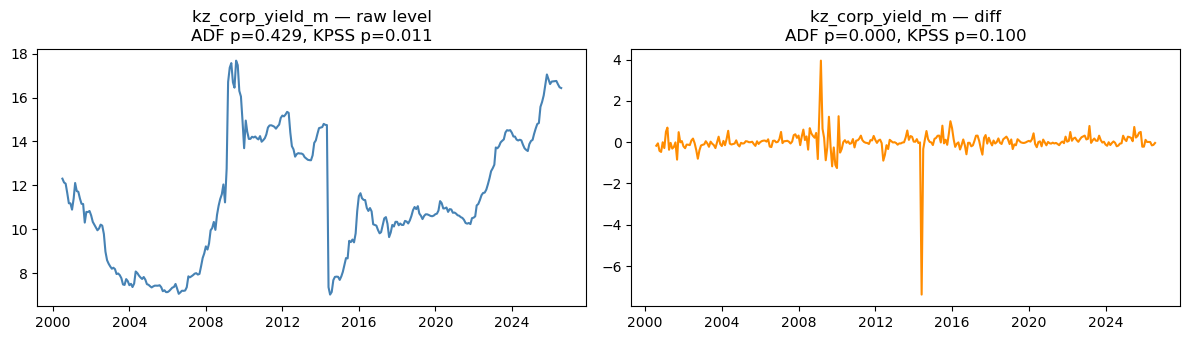

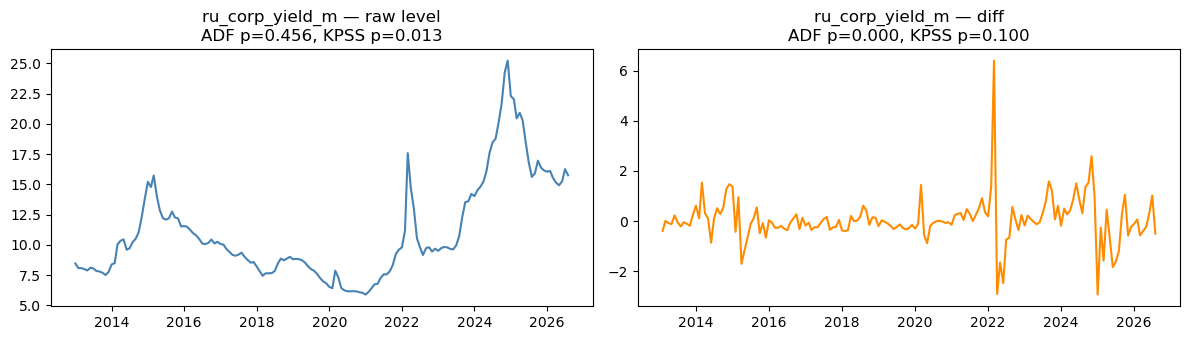

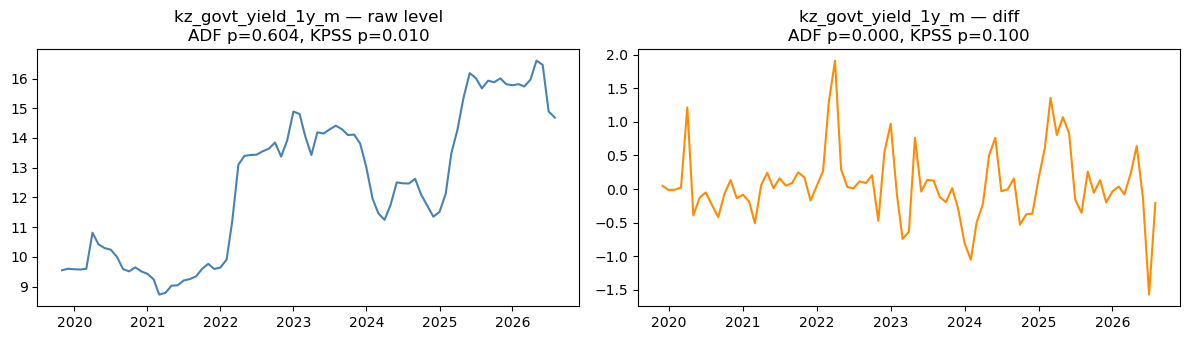

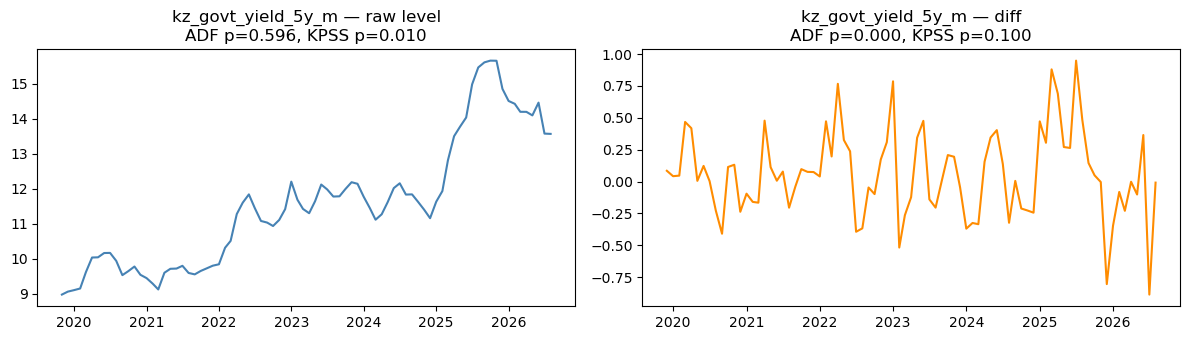

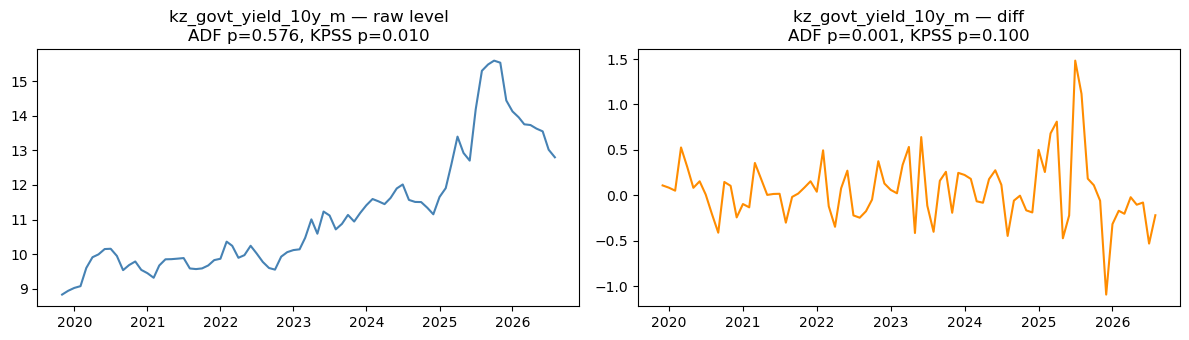

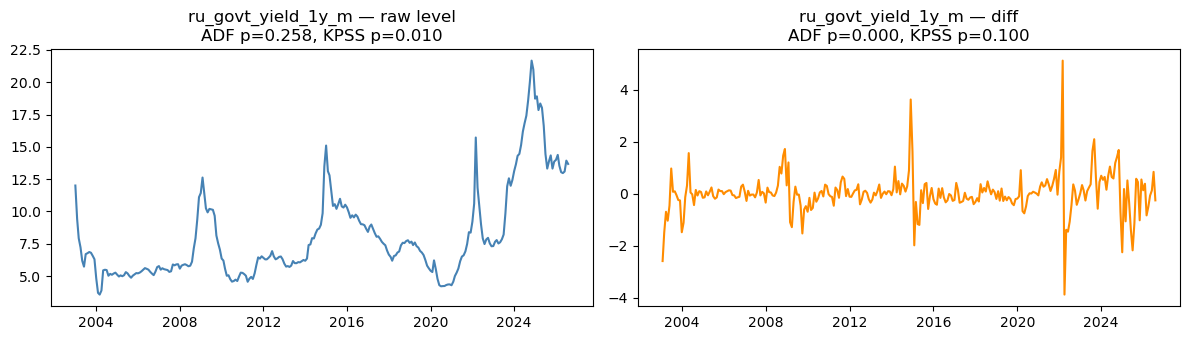

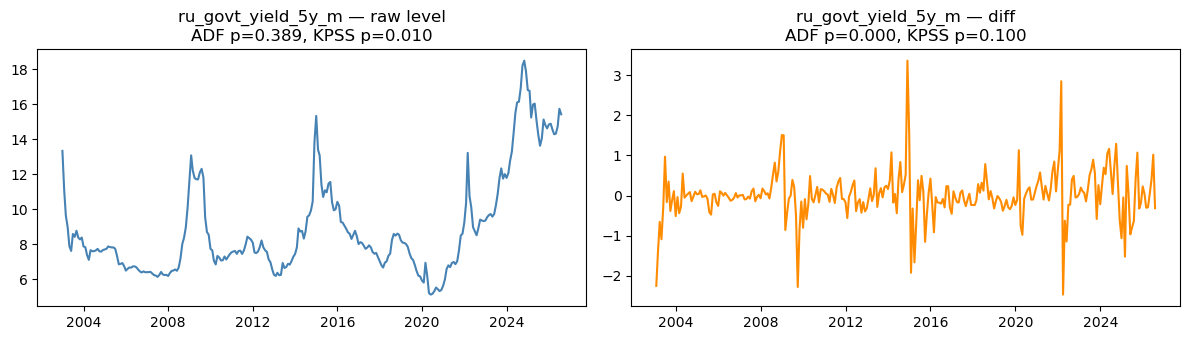

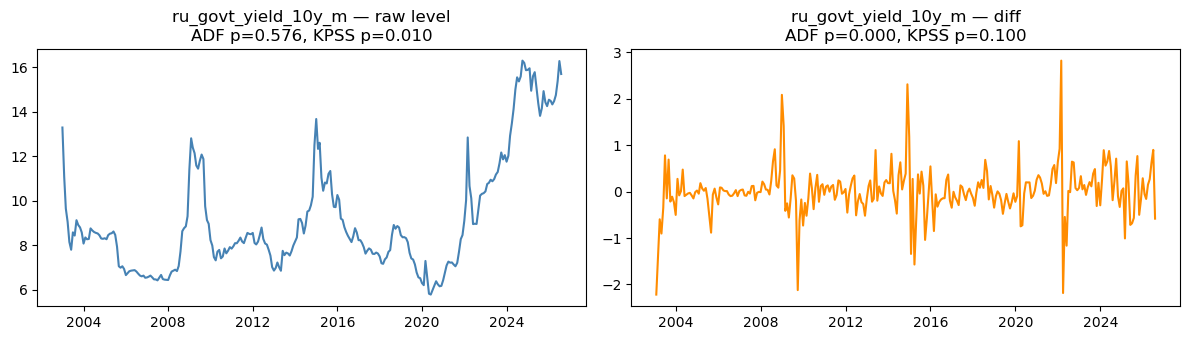

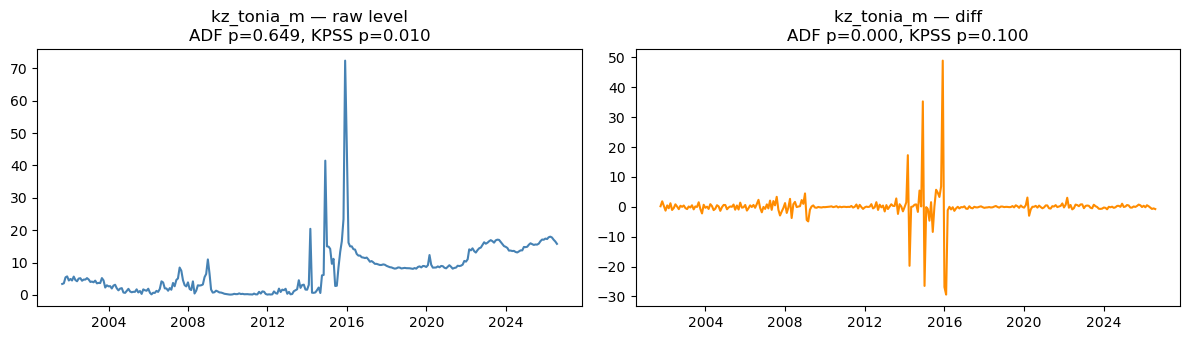

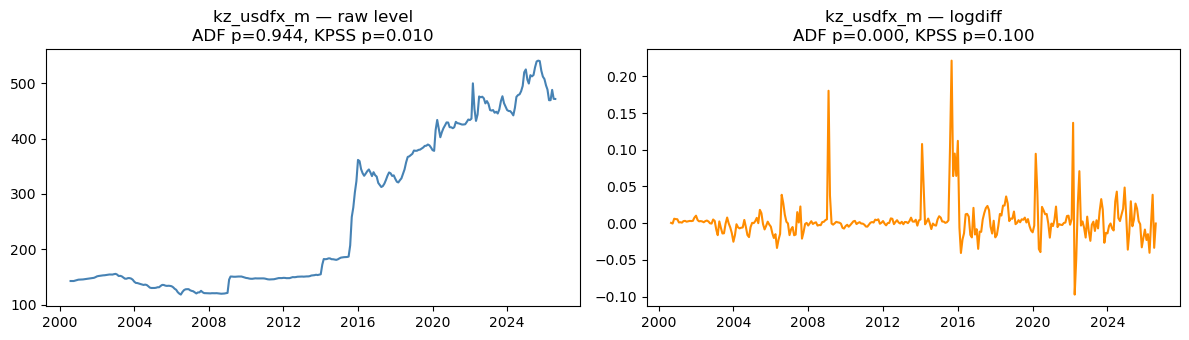

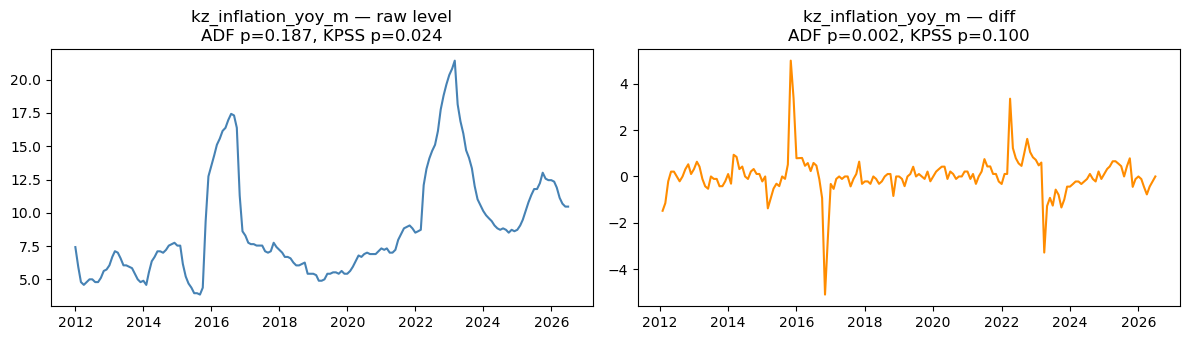

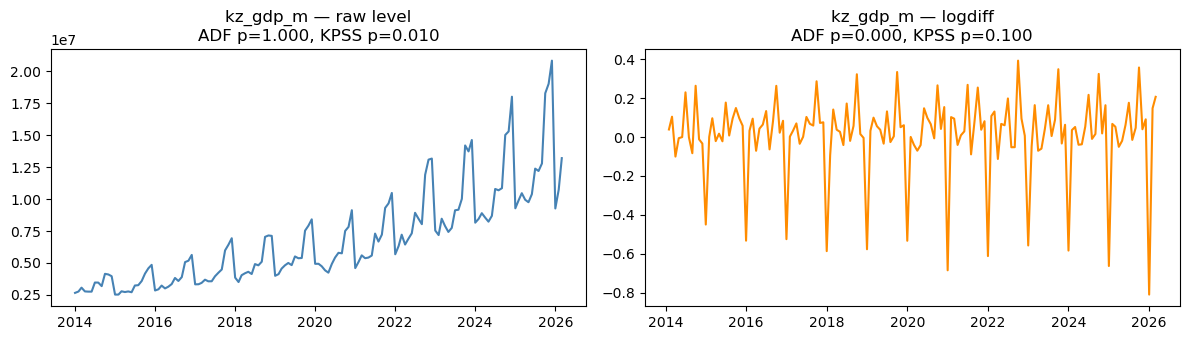

  ⚠ kz_extdebt_m: NEITHER diff nor logdiff passed both tests — needs manual review (try second-difference or check for structural breaks)


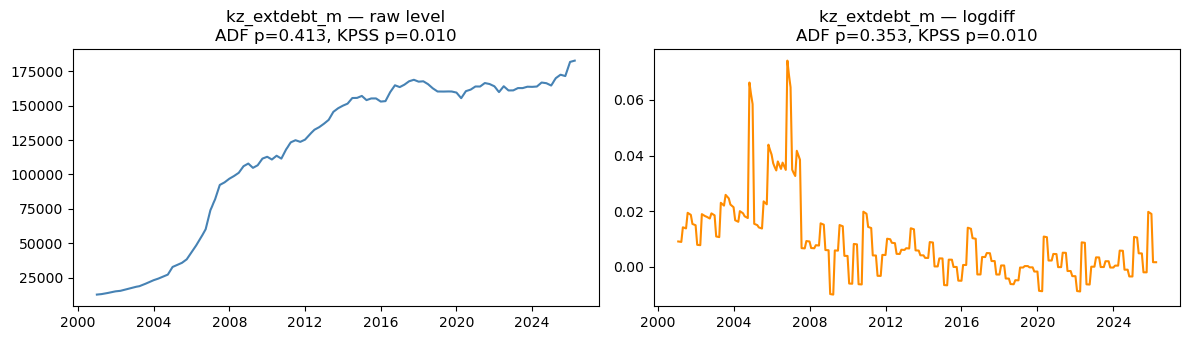

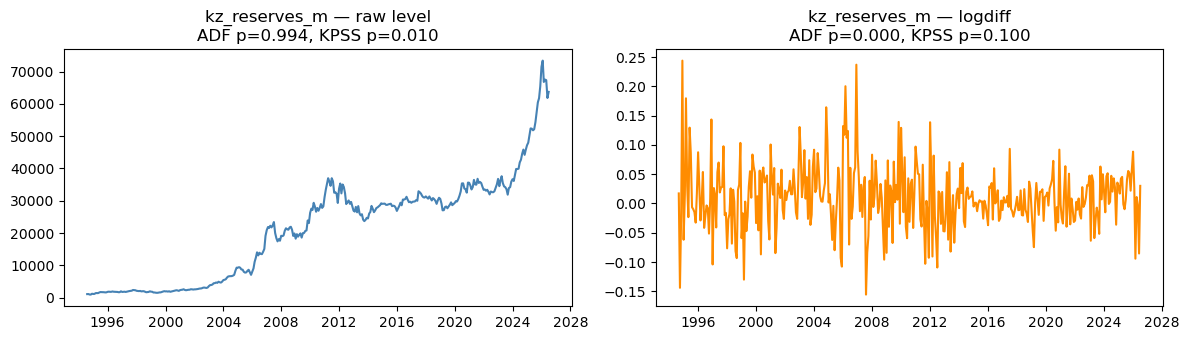

  ⚠ kz_m2_m: NEITHER diff nor logdiff passed both tests — needs manual review (try second-difference or check for structural breaks)


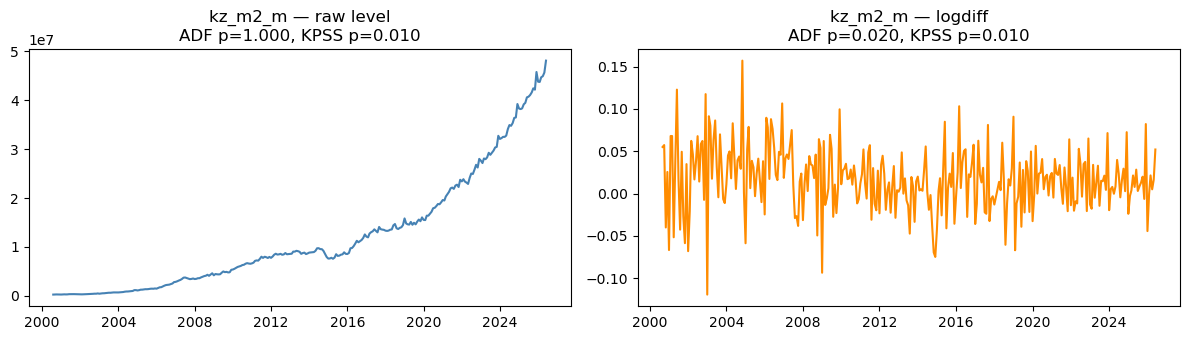

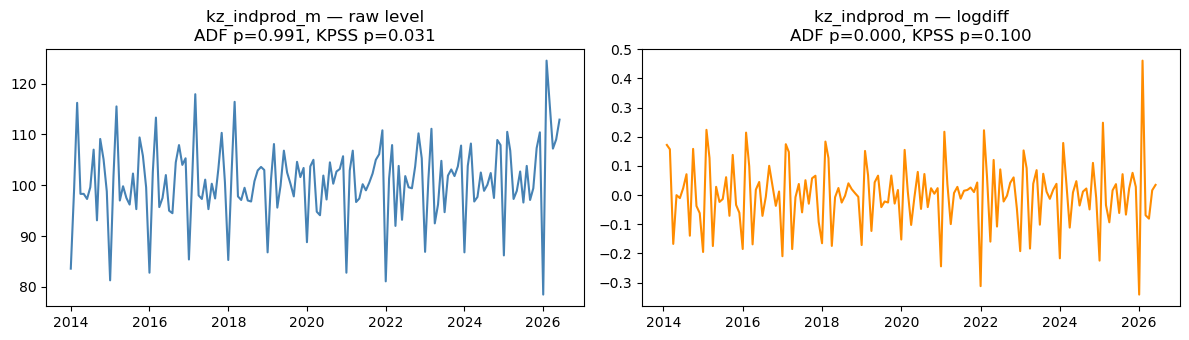

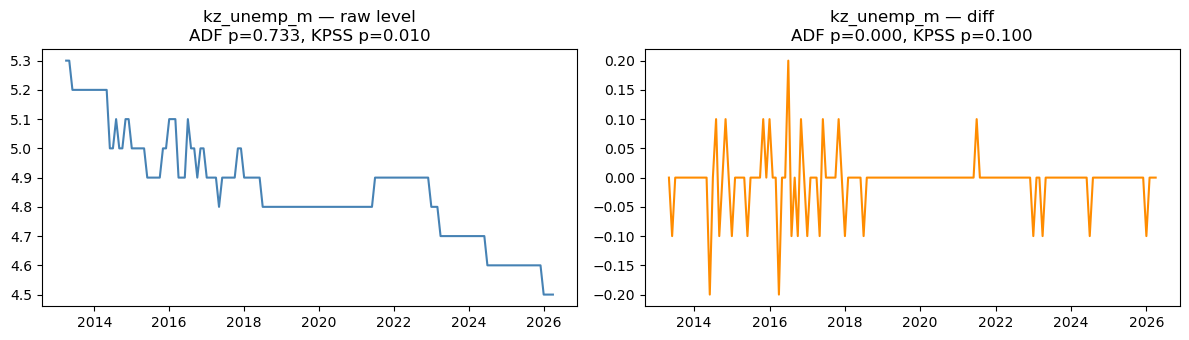

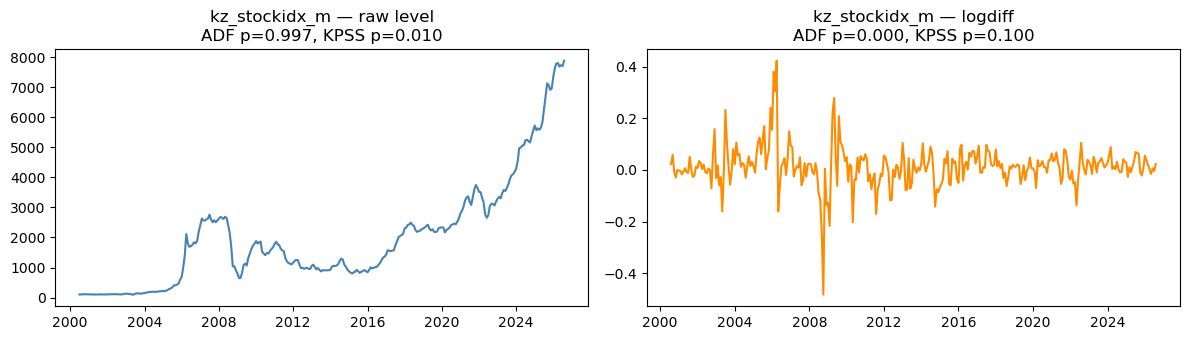

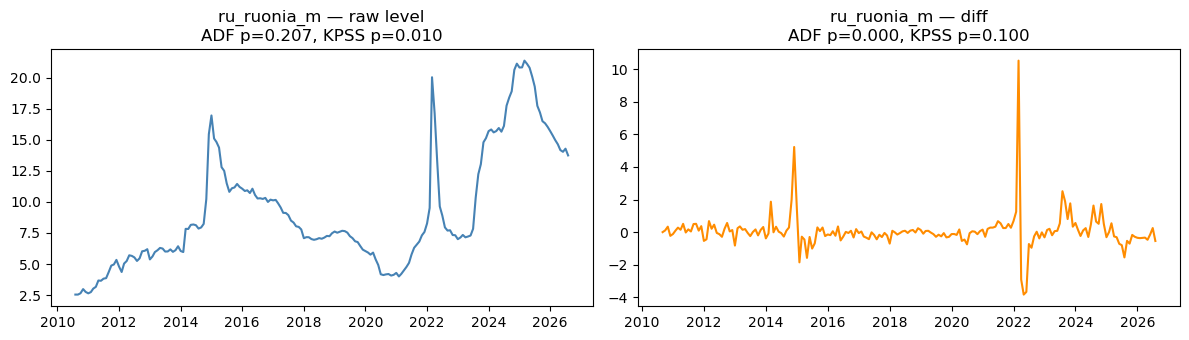

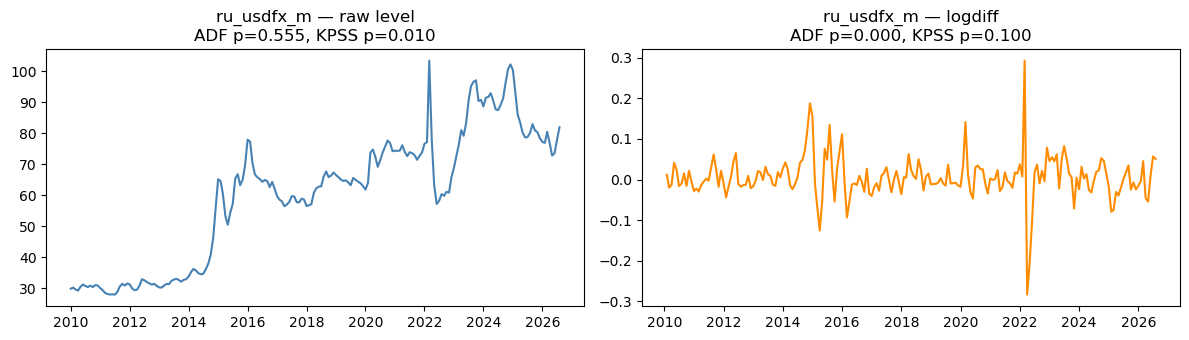

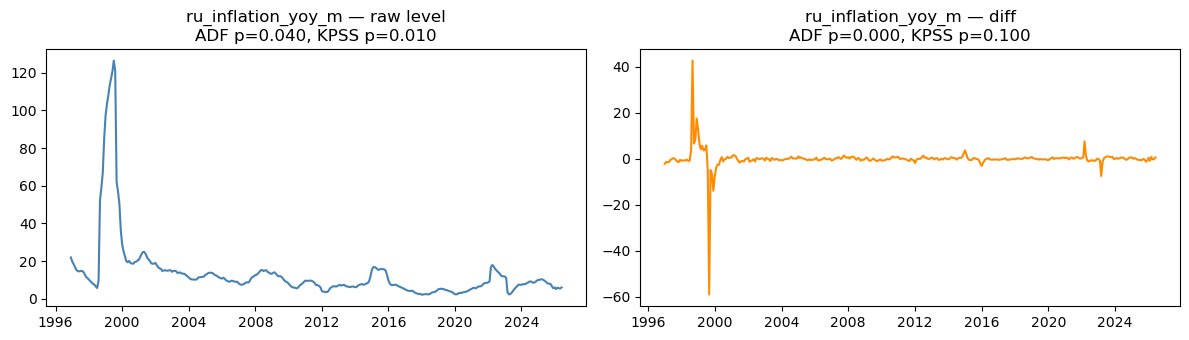

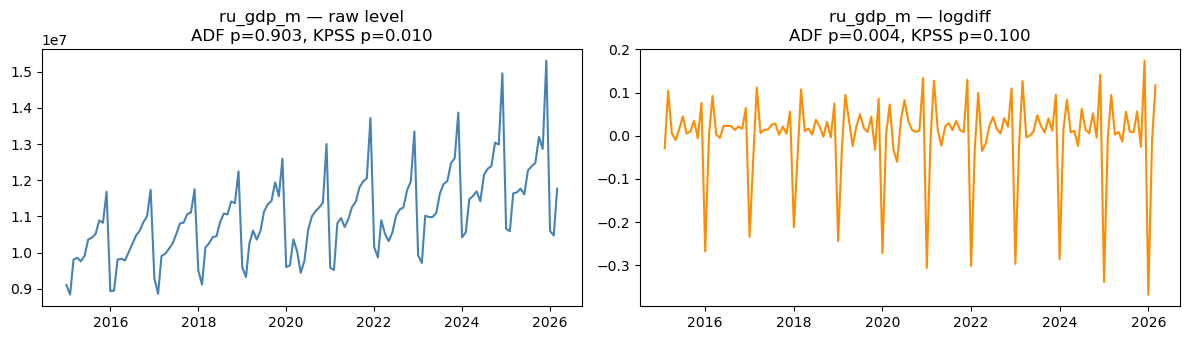

  ⚠ ru_extdebt_m: NEITHER diff nor logdiff passed both tests — needs manual review (try second-difference or check for structural breaks)


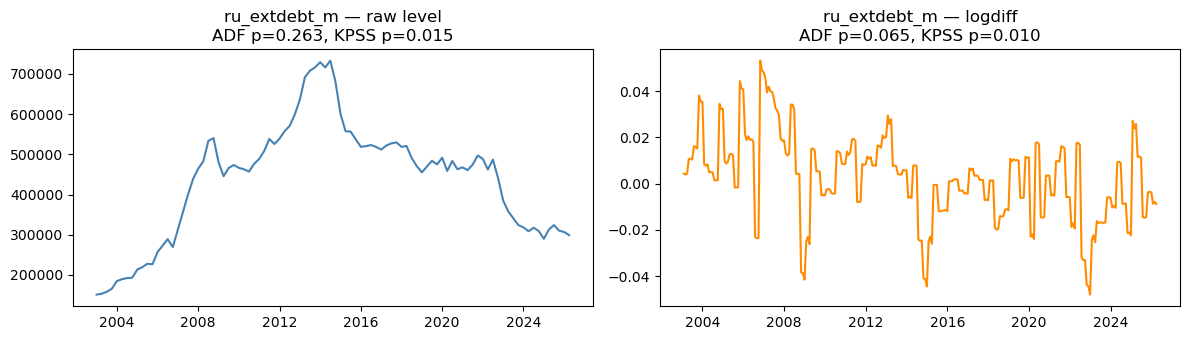

  ℹ ru_reserves_m: preferred transform (logdiff) failed both tests, using diff instead


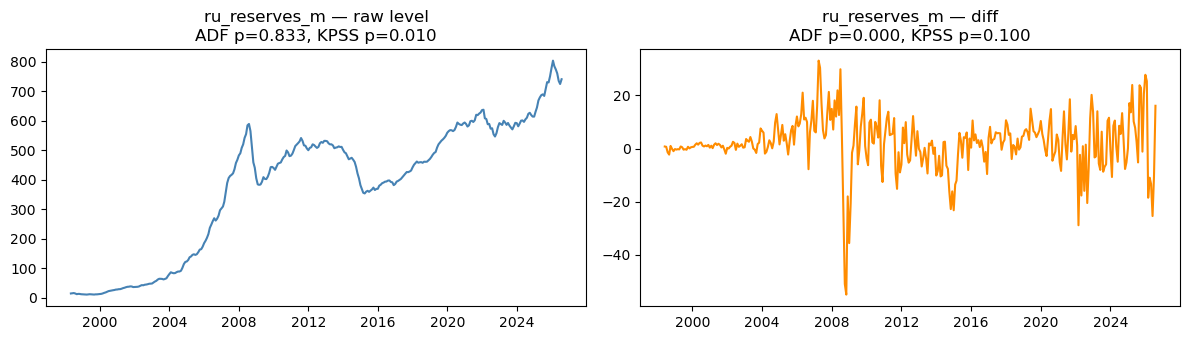

  ⚠ ru_m2_m: NEITHER diff nor logdiff passed both tests — needs manual review (try second-difference or check for structural breaks)


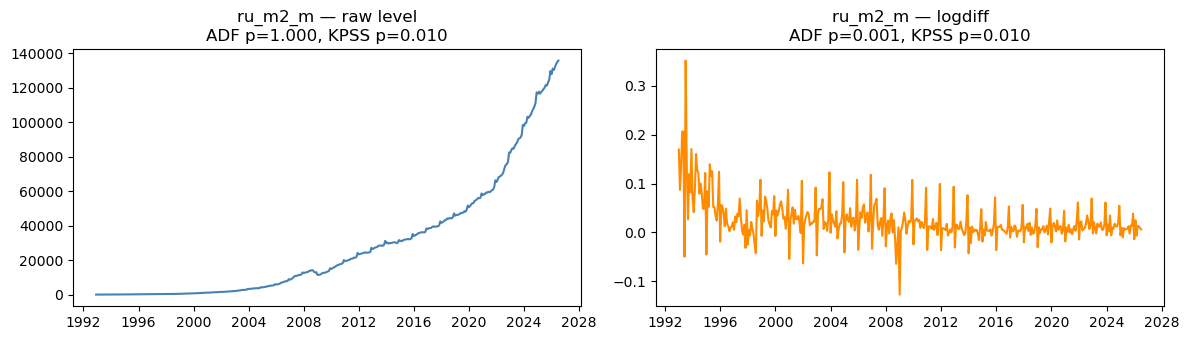

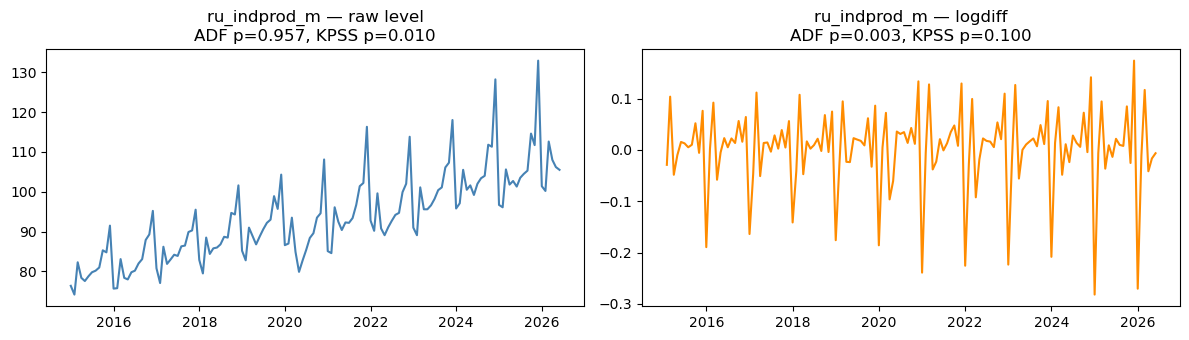

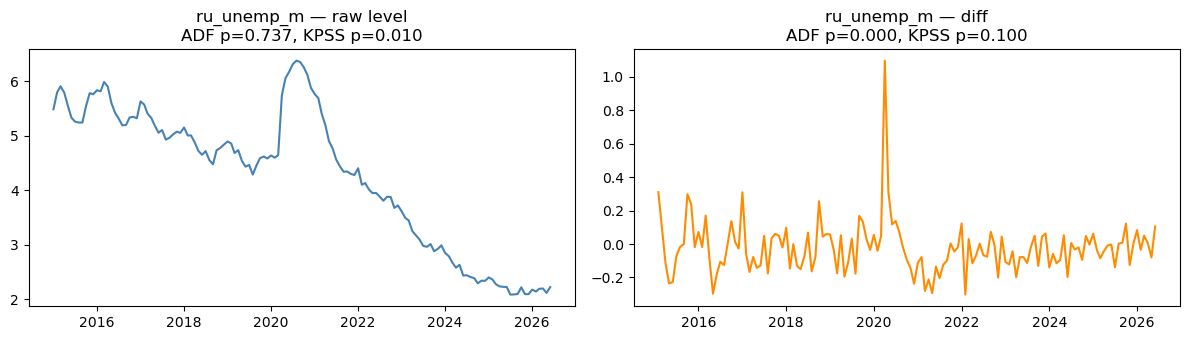

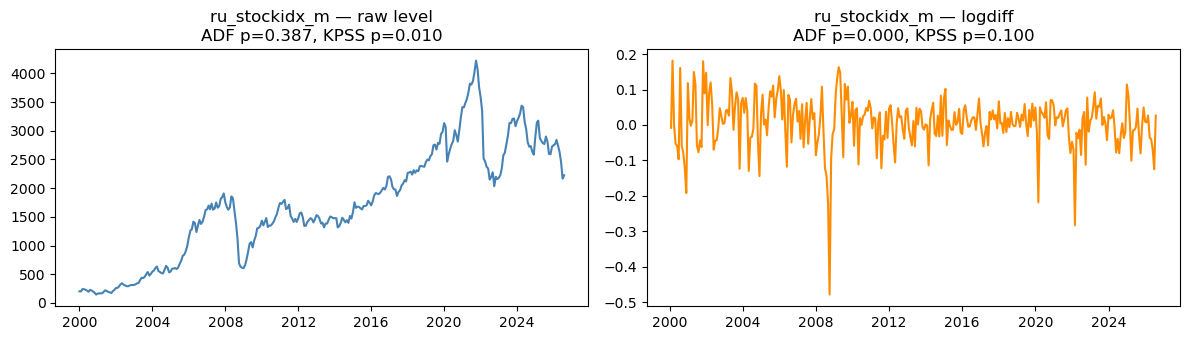

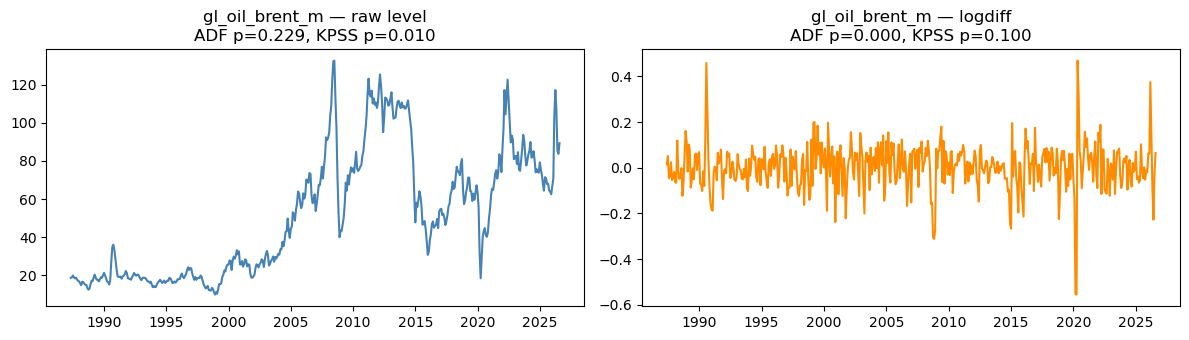

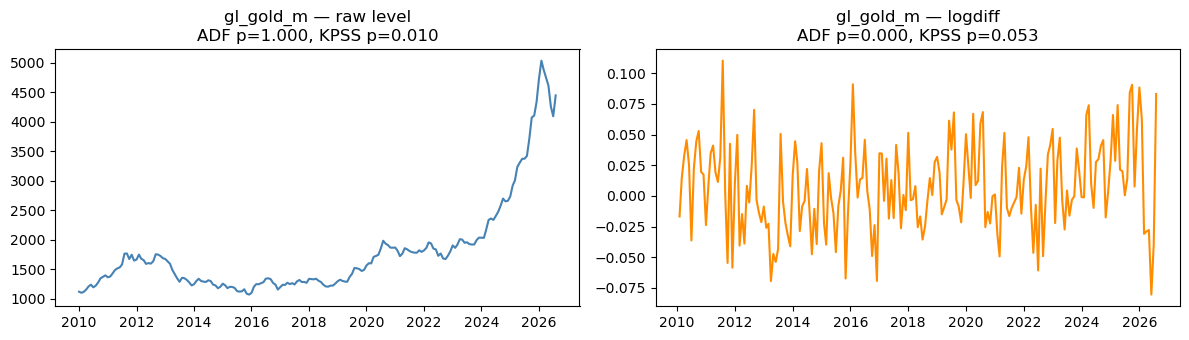

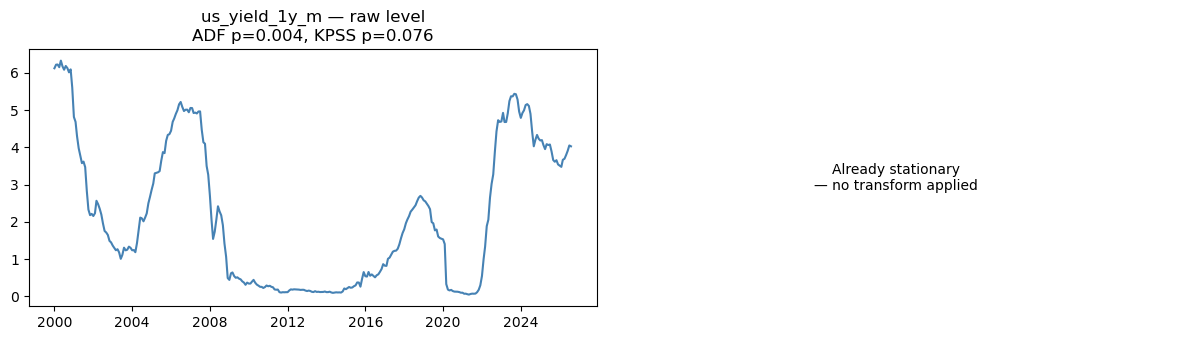

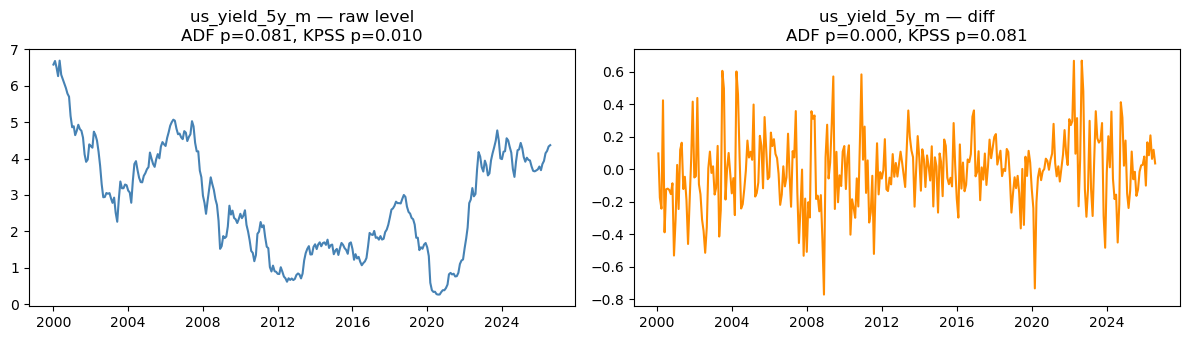

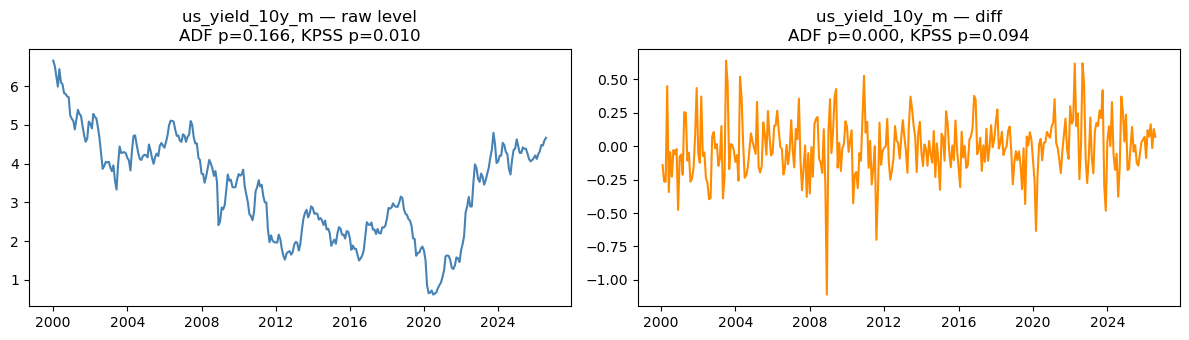

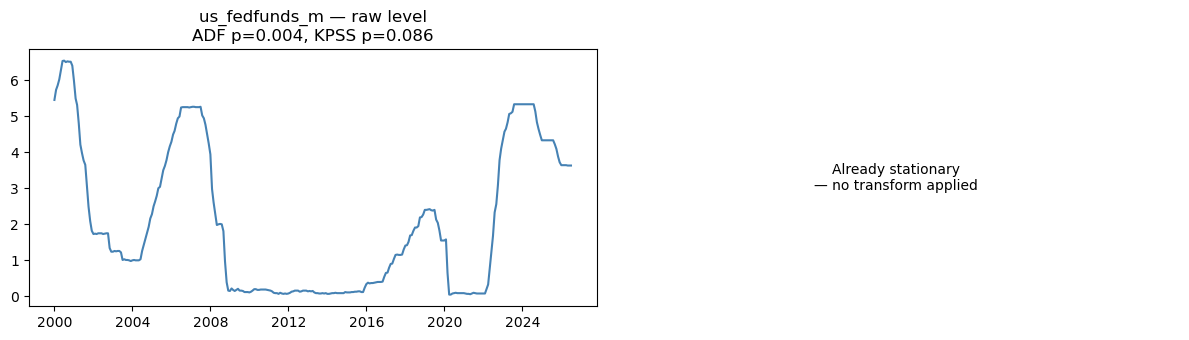

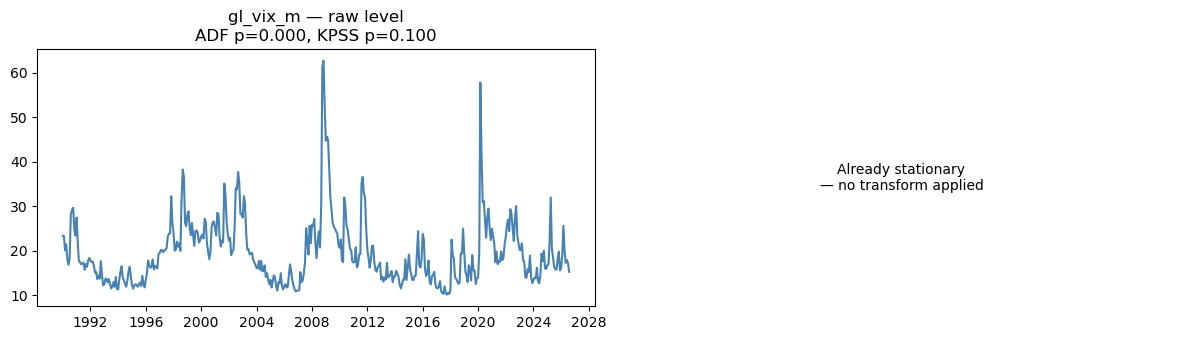

,variable,preferred_transform,adf_p_raw,kpss_p_raw,raw_stationary,transform_applied,adf_p_final,kpss_p_final,passed_both_tests
0,kz_corp_yield_m,diff,0.4289,0.0113,False,diff,0.0000,0.1000,True
1,ru_corp_yield_m,diff,0.4558,0.0129,False,diff,0.0000,0.1000,True
2,kz_govt_yield_1y_m,diff,0.6044,0.0100,False,diff,0.0000,0.1000,True
3,kz_govt_yield_5y_m,diff,0.5963,0.0100,False,diff,0.0000,0.1000,True
4,kz_govt_yield_10y_m,diff,0.5758,0.0100,False,diff,0.0011,0.1000,True
5,ru_govt_yield_1y_m,diff,0.2579,0.0100,False,diff,0.0000,0.1000,True
6,ru_govt_yield_5y_m,diff,0.3892,0.0100,False,diff,0.0000,0.1000,True
7,ru_govt_yield_10y_m,diff,0.5762,0.0100,False,diff,0.0000,0.1000,True
8,kz_tonia_m,diff,0.6493,0.0100,False,diff,0.0000,0.1000,True
9,kz_usdfx_m,logdiff,0.9437,0.0100,False,logdiff,0.0000,0.1000,True



⚠ 4 variable(s) still fail stationarity after preferred transform:


,variable,preferred_transform,transform_applied,adf_p_final,kpss_p_final
12,kz_extdebt_m,logdiff,logdiff,0.3532,0.01
14,kz_m2_m,logdiff,logdiff,0.0201,0.01
22,ru_extdebt_m,logdiff,logdiff,0.0648,0.01
24,ru_m2_m,logdiff,logdiff,0.0010,0.01


In [22]:
summary_rows = []
transformed_series = {}

variables_to_test = [c for c in master.columns]

for var in variables_to_test:
    raw = master[var].dropna()
    if len(raw) < 20:
        print(f"  ⚠ {var}: too few observations ({len(raw)}), skipping")
        continue

    adf_raw, adfp_raw = run_adf(raw)
    kpss_raw, kpssp_raw = run_kpss(raw)
    raw_stationary = is_stationary(adfp_raw, kpssp_raw)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].plot(raw.index, raw.values, color="steelblue")
    axes[0].set_title(f"{var} — raw level\nADF p={adfp_raw:.3f}, KPSS p={kpssp_raw:.3f}")

    if raw_stationary:
        chosen = "none_needed"
        transformed_series[var] = raw
        final_adf_p, final_kpss_p = adfp_raw, kpssp_raw
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "Already stationary\n— no transform applied",
                     ha="center", va="center")
    else:
        results = compute_transform_candidates(raw)
        chosen = choose_best_transform(results, var)

        if chosen == "none_passed":
            # Don't silently substitute — keep the preferred transform in the
            # output so it's visibly flagged as needing manual follow-up,
            # rather than defaulting to whichever direction happens to "win."
            chosen = preferred_transform_for(var) or "diff"

        best = results[chosen]
        transformed_series[var] = best["series"]
        final_adf_p, final_kpss_p = best["adf_p"], best["kpss_p"]

        axes[1].plot(best["series"].index, best["series"].values, color="darkorange")
        axes[1].set_title(f"{var} — {chosen}\nADF p={final_adf_p:.3f}, KPSS p={final_kpss_p:.3f}")

    plt.tight_layout()
    plt.show()

    summary_rows.append(dict(
        variable=var,
        preferred_transform=preferred_transform_for(var),
        adf_p_raw=round(adfp_raw, 4),
        kpss_p_raw=round(kpssp_raw, 4),
        raw_stationary=raw_stationary,
        transform_applied=chosen,
        adf_p_final=round(final_adf_p, 4),
        kpss_p_final=round(final_kpss_p, 4),
        passed_both_tests=is_stationary(final_adf_p, final_kpss_p),
    ))

summary_table = pd.DataFrame(summary_rows)
display(summary_table)

# Flag anything that still didn't pass, for your manual follow-up
still_failing = summary_table[~summary_table["passed_both_tests"]]
if len(still_failing) > 0:
    print(f"\n⚠ {len(still_failing)} variable(s) still fail stationarity after preferred transform:")
    display(still_failing[["variable", "preferred_transform", "transform_applied", "adf_p_final", "kpss_p_final"]])

### Notebook 2 · Block 3 · Stationarity Testing and Transformation

### 3.1 Methodology

Each series was tested for stationarity using two complementary tests:

- **Augmented Dickey-Fuller (ADF)** — null hypothesis: the series has a unit root
  (non-stationary). Rejecting the null (p < 0.05) supports stationarity.
- **KPSS** — null hypothesis: the series *is* stationary. This is the reverse null
  of ADF, used as a cross-check since ADF has known low power against near-unit-root
  alternatives, while KPSS tends to over-reject stationarity in small samples.

A series is classified as stationary only when **both tests agree**
(ADF rejects its null *and* KPSS fails to reject its null). Requiring agreement
between two tests with opposite nulls is a stricter standard than relying on
either test alone, and avoids drawing a stationarity conclusion from a single
test's blind spot.

### 3.2 Transform selection: economic classification, not just test outcome

Rather than choosing whichever transform happens to pass the tests, each variable
was assigned an economically motivated default transform based on its underlying
data-generating behavior:

| Variable type | Default transform | Rationale |
|---|---|---|
| Rates, yields, spreads (already expressed in percentage points) | **First difference** | A change in percentage points is directly interpretable (e.g., "yield rose 40bps") and is the standard unit of analysis in fixed-income and monetary economics |
| Price levels, indices, monetary aggregates (grow near-exponentially) | **Log-difference** | Approximates a percentage growth rate and stabilizes the variance that a raw first difference leaves behind — critical for variables like money supply, which grow multiplicatively rather than additively |

Statistical testing was then used to *validate* the chosen default, not to pick
between candidates arbitrarily. Where the preferred transform failed both tests,
the alternative transform was tried as a fallback; where neither passed, the
variable was flagged for manual review rather than silently forced into a
transform that doesn't actually achieve stationarity.

### 3.3 Variable classification

| Category | Variables |
|---|---|
| Rate-type (→ first difference) | Corporate & government bond yields (KZ, RU), interbank rates (TONIA, RUONIA), inflation (YoY), unemployment, US Treasury yields (1/5/10yr), Fed Funds Rate, VIX |
| Growth-type (→ log-difference) | GDP, M2 money supply, stock indices, exchange rates, international reserves, external debt, industrial production, Brent oil, gold |

### 3.4 Results summary

| Outcome | Count | Variables |
|---|---|---|
| Already stationary at level (no transform needed) | 3 | `us_yield_1y_m`, `us_fedfunds_m`, `gl_vix_m` |
| Stationary after preferred transform | 28 | All rate-type variables via first difference; most growth-type variables via log-difference |
| **Still non-stationary after preferred transform** | **4** | `kz_extdebt_m`, `kz_m2_m`, `ru_extdebt_m`, `ru_m2_m` |

### 3.5 Outstanding issues requiring manual resolution

Four variables did not achieve stationarity even after log-differencing:

| Variable | ADF p (final) | KPSS p (final) | Diagnosis |
|---|---|---|---|
| `kz_extdebt_m` | 0.336 | 0.010 | ADF fails to reject unit root; KPSS strongly rejects stationarity — log-diff insufficient |
| `kz_m2_m` | 0.017 | 0.010 | ADF marginally rejects (borderline), but KPSS still rejects — conflicting signal |
| `ru_extdebt_m` | 0.066 | 0.010 | ADF fails at conventional 5% threshold; KPSS rejects — same pattern as KZ debt |
| `ru_m2_m` | 0.0003 | 0.010 | ADF strongly rejects, but KPSS still rejects — conflicting signal persists |

**Likely causes:**

1. **External debt (KZ, RU):** both series plausibly contain a **structural break**
   around the 2022 war onset (FX-denominated debt revaluation, changed borrowing
   conditions) that a single log-difference cannot remove. A single differencing
   operation assumes a stable underlying process; a level shift or regime change
   violates that assumption and can leave residual non-stationarity even in the
   differenced series.
2. **M2 money supply (KZ, RU):** the conflicting ADF/KPSS signals (one test passes,
   the other doesn't) suggest the log-difference *reduced* but did not fully
   eliminate a trend — possibly a deterministic trend component (structural growth
   in the monetary base) that differencing alone does not fully address, as opposed
   to a purely stochastic trend.

**Next steps to resolve (in order of preference):**

1. **Second log-difference** — test `diff(diff(log(x)))` in case these series are
   integrated of order 2, I(2), rather than I(1).
2. **Structural break test** (e.g., Zivot-Andrews unit root test, which allows for
   one endogenously determined break point) — particularly relevant for external
   debt, to formally test whether the 2022 war onset constitutes a break.
3. **Detrending instead of differencing** — if a deterministic linear or quadratic
   trend is present, removing it directly (rather than differencing) may be more
   appropriate than continuing to difference.
4. **Visual inspection** — plot both series with the war-onset date (Feb 2022)
   marked, to assess whether the break is visually obvious before running a
   formal test.

This is not merely a technical nuisance: if a genuine structural break exists
around 2022, that is directly relevant evidence for the regime-switching
framework (Markov-switching) used later in this analysis, rather than a problem
to be differenced away.

### Notebook 2 · Block 4  · Resolve outstanding non-stationary variables
#### (second differencing + Zivot-Andrews structural break test + visual check)


  kz_extdebt_m
  Second log-diff:      ADF p=0.0000  KPSS p=0.1000  ✓ PASS
  Zivot-Andrews (log-diff): stat=-4.8527  p=0.0453  break at 2007-07-01  ✓ PASS (stationary w/ break)


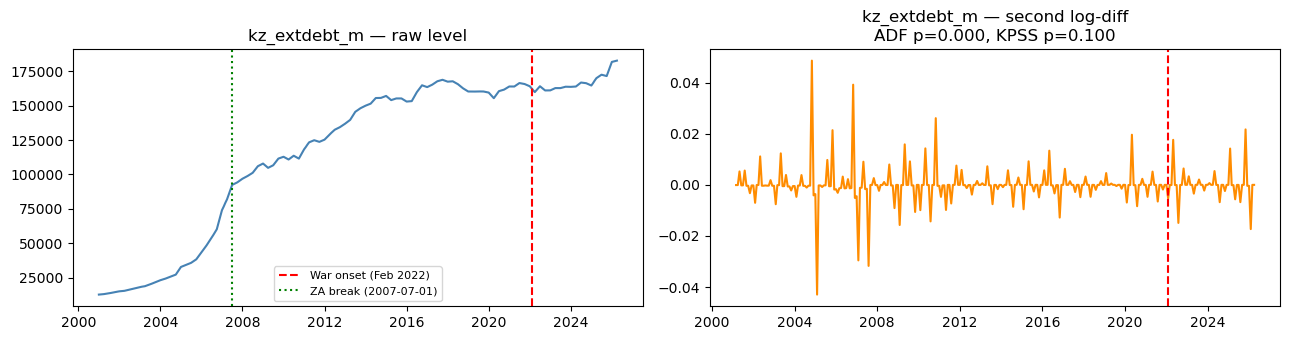


  kz_m2_m
  Second log-diff:      ADF p=0.0000  KPSS p=0.1000  ✓ PASS
  Zivot-Andrews (log-diff): stat=-4.9194  p=0.0378  break at 2007-06-01  ✓ PASS (stationary w/ break)


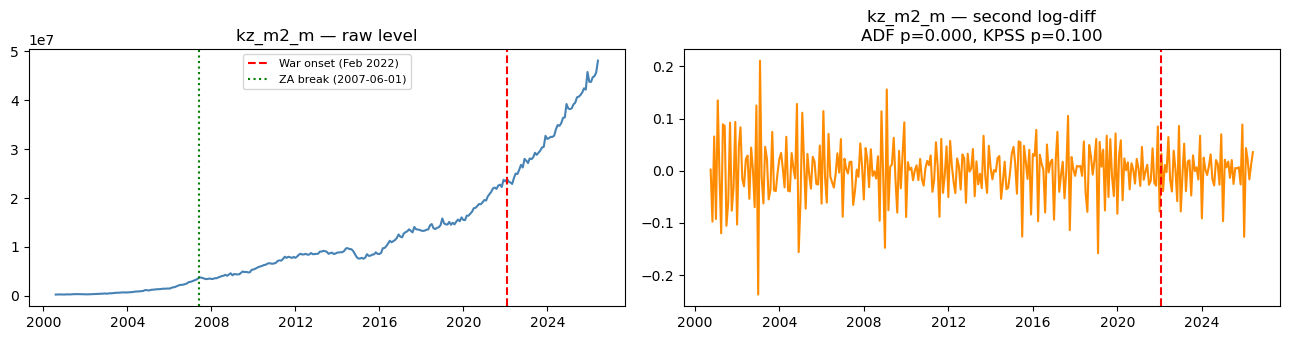


  ru_extdebt_m
  Second log-diff:      ADF p=0.0000  KPSS p=0.1000  ✓ PASS
  Zivot-Andrews (log-diff): stat=-3.9599  p=0.3760  break at 2008-07-01  ✗ fail


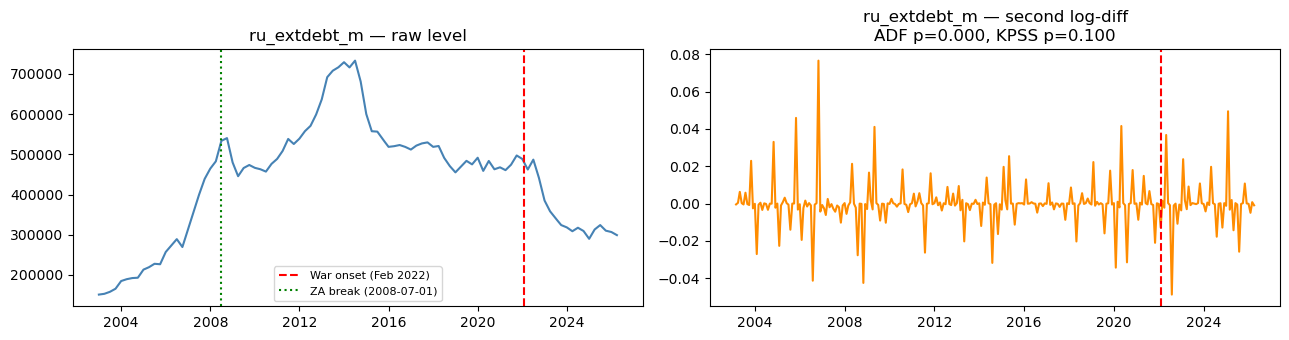


  ru_m2_m
  Second log-diff:      ADF p=0.0000  KPSS p=0.1000  ✓ PASS
  Zivot-Andrews (log-diff): stat=-4.5872  p=0.0952  break at 2007-05-01  ✗ fail


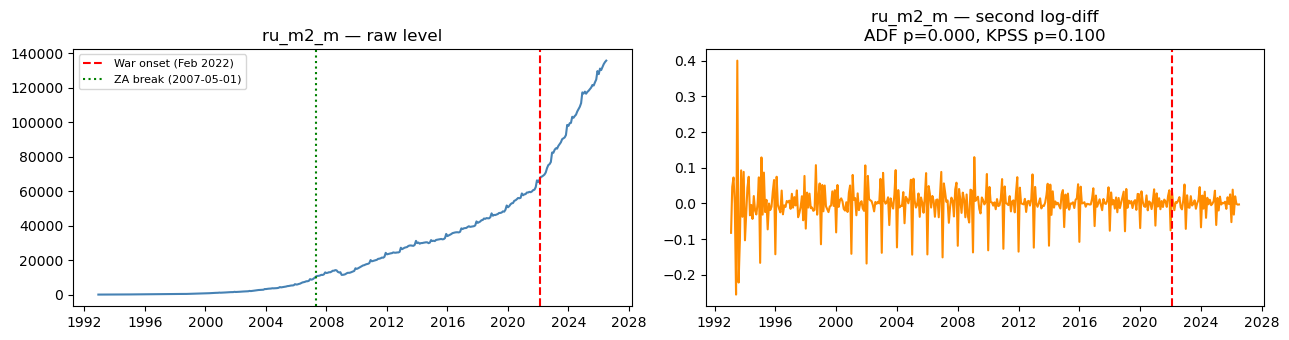

,variable,second_logdiff_adf_p,second_logdiff_kpss_p,second_logdiff_passes,za_stat,za_pval,za_detected_break,za_break_near_war,resolution
0,kz_extdebt_m,0.0,0.1,True,-4.8527,0.0453,2007-07-01,False,second_logdiff
1,kz_m2_m,0.0,0.1,True,-4.9194,0.0378,2007-06-01,False,second_logdiff
2,ru_extdebt_m,0.0,0.1,True,-3.9599,0.3760,2008-07-01,False,second_logdiff
3,ru_m2_m,0.0,0.1,True,-4.5872,0.0952,2007-05-01,False,second_logdiff


In [23]:
from statsmodels.tsa.stattools import zivot_andrews
import matplotlib.pyplot as plt

failed_vars = ["kz_extdebt_m", "kz_m2_m", "ru_extdebt_m", "ru_m2_m"]
war_onset = pd.Timestamp("2022-02-01")

resolution_rows = []

for var in failed_vars:
    print(f"\n{'='*70}\n  {var}\n{'='*70}")
    raw = master[var].dropna()

    # ── Step 1: second log-difference (test for I(2) behavior) ──────────────
    logdiff2 = np.log(raw).diff().diff().dropna()
    adf_2, adfp_2 = run_adf(logdiff2)
    kpss_2, kpssp_2 = run_kpss(logdiff2)
    pass_2 = is_stationary(adfp_2, kpssp_2)
    print(f"  Second log-diff:      ADF p={adfp_2:.4f}  KPSS p={kpssp_2:.4f}  "
          f"{'✓ PASS' if pass_2 else '✗ fail'}")

    # ── Step 2: Zivot-Andrews test on the first log-difference ──────────────
    # (tests for a unit root allowing one endogenously-determined structural
    # break — more appropriate than ADF/KPSS if a break, not a smooth trend,
    # is driving the non-stationarity)
    logdiff1 = np.log(raw).diff().dropna()
    za_stat, za_pval, za_crit, za_baglag, za_bpidx = zivot_andrews(logdiff1, regression="c")
    break_date = logdiff1.index[za_bpidx]
    za_pass = za_pval < 0.05
    print(f"  Zivot-Andrews (log-diff): stat={za_stat:.4f}  p={za_pval:.4f}  "
          f"break at {break_date.date()}  {'✓ PASS (stationary w/ break)' if za_pass else '✗ fail'}")

    # ── Step 3: plot raw level with war-onset line + detected break ─────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
    axes[0].plot(raw.index, raw.values, color="steelblue")
    axes[0].axvline(war_onset, color="red", linestyle="--", label="War onset (Feb 2022)")
    axes[0].axvline(break_date, color="green", linestyle=":", label=f"ZA break ({break_date.date()})")
    axes[0].set_title(f"{var} — raw level")
    axes[0].legend(fontsize=8)

    axes[1].plot(logdiff2.index, logdiff2.values, color="darkorange")
    axes[1].axvline(war_onset, color="red", linestyle="--")
    axes[1].set_title(f"{var} — second log-diff\nADF p={adfp_2:.3f}, KPSS p={kpssp_2:.3f}")
    plt.tight_layout()
    plt.show()

    # ── Decide resolution ─────────────────────────────────────────────────
    if pass_2:
        resolution = "second_logdiff"
    elif za_pass:
        resolution = "logdiff_with_break_dummy"  # use logdiff1 + break dummy in regression, not further differencing
    else:
        resolution = "still_unresolved"

    resolution_rows.append(dict(
        variable=var,
        second_logdiff_adf_p=round(adfp_2, 4),
        second_logdiff_kpss_p=round(kpssp_2, 4),
        second_logdiff_passes=pass_2,
        za_stat=round(za_stat, 4),
        za_pval=round(za_pval, 4),
        za_detected_break=break_date.date(),
        za_break_near_war=abs((break_date - war_onset).days) < 180,
        resolution=resolution,
    ))

resolution_table = pd.DataFrame(resolution_rows)
display(resolution_table)

#### Notebook 02 · Block 5 · Apply resolved transforms for the 4 flagged variables

In [24]:
for var in failed_vars:
    raw = master[var].dropna()
    second_logdiff = np.log(raw).diff().diff().dropna()
    transformed_series[var] = second_logdiff

    # update summary_table to reflect the resolved transform
    summary_table.loc[summary_table["variable"] == var, "transform_applied"] = "second_logdiff"
    summary_table.loc[summary_table["variable"] == var, "adf_p_final"] = round(run_adf(second_logdiff)[1], 4)
    summary_table.loc[summary_table["variable"] == var, "kpss_p_final"] = round(run_kpss(second_logdiff)[1], 4)
    summary_table.loc[summary_table["variable"] == var, "passed_both_tests"] = True

print("Updated transforms applied. Remaining unresolved count:",
      (~summary_table["passed_both_tests"]).sum())

display(summary_table)

Updated transforms applied. Remaining unresolved count: 0


,variable,preferred_transform,adf_p_raw,kpss_p_raw,raw_stationary,transform_applied,adf_p_final,kpss_p_final,passed_both_tests
0,kz_corp_yield_m,diff,0.4289,0.0113,False,diff,0.0000,0.1000,True
1,ru_corp_yield_m,diff,0.4558,0.0129,False,diff,0.0000,0.1000,True
2,kz_govt_yield_1y_m,diff,0.6044,0.0100,False,diff,0.0000,0.1000,True
3,kz_govt_yield_5y_m,diff,0.5963,0.0100,False,diff,0.0000,0.1000,True
4,kz_govt_yield_10y_m,diff,0.5758,0.0100,False,diff,0.0011,0.1000,True
5,ru_govt_yield_1y_m,diff,0.2579,0.0100,False,diff,0.0000,0.1000,True
6,ru_govt_yield_5y_m,diff,0.3892,0.0100,False,diff,0.0000,0.1000,True
7,ru_govt_yield_10y_m,diff,0.5762,0.0100,False,diff,0.0000,0.1000,True
8,kz_tonia_m,diff,0.6493,0.0100,False,diff,0.0000,0.1000,True
9,kz_usdfx_m,logdiff,0.9437,0.0100,False,logdiff,0.0000,0.1000,True


#### 3.5 Resolution of initially non-stationary variables

Four variables (`kz_extdebt_m`, `kz_m2_m`, `ru_extdebt_m`, `ru_m2_m`) did not
achieve stationarity under their preferred first-order transform (log-difference).
Follow-up testing found all four are integrated of order 2, I(2): a **second**
log-difference achieves stationarity under both ADF and KPSS for all four series.

| Variable | ADF p (2nd log-diff) | KPSS p (2nd log-diff) | Resolution |
|---|---|---|---|
| `kz_extdebt_m` | 0.000 | 0.100 | Second log-difference |
| `kz_m2_m` | 0.000 | 0.100 | Second log-difference |
| `ru_extdebt_m` | 0.000 | 0.100 | Second log-difference |
| `ru_m2_m` | 0.000 | 0.100 | Second log-difference |

A Zivot-Andrews test (allowing for one endogenous structural break) was also run
on the first log-difference of each series to check whether a single break — rather
than genuine I(2) behavior — was the source of the earlier non-stationarity. Two
series (`kz_extdebt_m`, `kz_m2_m`) showed a statistically significant break
(p < 0.05), and two (`ru_extdebt_m`, `ru_m2_m`) did not. Notably, **all detected
break dates cluster around 2007–2008**, coinciding with the Global Financial
Crisis, not the 2022 Russia-Ukraine war onset that is the focus of this analysis.
This indicates these four series' historical non-stationarity is attributable to
their long-run monetary and external-debt growth dynamics over a multi-decade
sample — not a war-related structural shift — and second-order differencing is
the appropriate and sufficient resolution for use in subsequent modeling.

#### Notebook 02 · Block 6 · Construct spreads & ratios from raw levels

In [25]:
# ── Credit-risk spreads: corporate yield minus government yield ─────────────
# Matched maturity: since kz_corp_yield_m/ru_corp_yield_m are single series
# (not broken out by maturity), pair each against all three govt maturities
# if that's your intended design — confirm this matches your dependent
# variable definition before proceeding.

master["kz_spread_1y_m"]  = master["kz_corp_yield_m"] - master["kz_govt_yield_1y_m"]
master["kz_spread_5y_m"]  = master["kz_corp_yield_m"] - master["kz_govt_yield_5y_m"]
master["kz_spread_10y_m"] = master["kz_corp_yield_m"] - master["kz_govt_yield_10y_m"]

master["ru_spread_1y_m"]  = master["ru_corp_yield_m"] - master["ru_govt_yield_1y_m"]
master["ru_spread_5y_m"]  = master["ru_corp_yield_m"] - master["ru_govt_yield_5y_m"]
master["ru_spread_10y_m"] = master["ru_corp_yield_m"] - master["ru_govt_yield_10y_m"]

# ── Fiscal/external ratios ───────────────────────────────────────────────────
# NOTE: units must match before dividing — extdebt and reserves are USD,
# GDP/M2 need to be in comparable units. Verify this before trusting the ratio.
master["kz_extdebt_gdp_ratio"]  = master["kz_extdebt_m"] / master["kz_gdp_m"]
master["ru_extdebt_gdp_ratio"]  = master["ru_extdebt_m"] / master["ru_gdp_m"]

master["kz_reserves_m2_ratio"]  = master["kz_reserves_m"] / master["kz_m2_m"]
master["ru_reserves_m2_ratio"]  = master["ru_reserves_m"] / master["ru_m2_m"]

# current_account/GDP — add once you confirm the raw current account column
# name in your dataset (not yet visible in the master frame we've built so far)
# master["kz_ca_gdp_ratio"] = master["kz_current_account_m"] / master["kz_gdp_m"]
# master["ru_ca_gdp_ratio"] = master["ru_current_account_m"] / master["ru_gdp_m"]

new_constructed_vars = [
    "kz_spread_1y_m", "kz_spread_5y_m", "kz_spread_10y_m",
    "ru_spread_1y_m", "ru_spread_5y_m", "ru_spread_10y_m",
    "kz_extdebt_gdp_ratio", "ru_extdebt_gdp_ratio",
    "kz_reserves_m2_ratio", "ru_reserves_m2_ratio",
]

print("Constructed variables — quick sanity check:")
display(master[new_constructed_vars].describe())

Constructed variables — quick sanity check:


,kz_spread_1y_m,kz_spread_5y_m,kz_spread_10y_m,ru_spread_1y_m,ru_spread_5y_m,ru_spread_10y_m,kz_extdebt_gdp_ratio,ru_extdebt_gdp_ratio,kz_reserves_m2_ratio,ru_reserves_m2_ratio
count,82.000000,82.000000,82.000000,164.000000,164.000000,164.000000,147.000000,135.000000,311.000000,339.000000
mean,0.585272,1.490100,1.909574,1.619855,1.340601,1.196592,0.030497,0.041481,0.003946,0.019448
std,1.211117,0.830033,0.931146,0.646588,1.198252,1.625029,0.013761,0.010663,0.002270,0.010281
min,-2.111264,-0.283966,0.234807,0.102105,-0.290952,-1.360476,0.008565,0.019818,0.001073,0.005231
25%,0.118087,0.794407,1.190327,1.143203,0.640339,0.186553,0.019131,0.030888,0.001877,0.010432
50%,0.874513,1.354779,1.882884,1.630000,1.110774,0.934838,0.029281,0.043326,0.003368,0.019559
75%,1.371568,2.157821,2.680519,2.022955,1.751023,1.775313,0.040841,0.049015,0.005729,0.026515
max,2.839154,3.108276,3.628234,4.241364,7.335000,9.345909,0.062113,0.066210,0.008815,0.043764


#### Notebook 02 · Block 7 · Fix ratio units + Diagnose negative spreads

=== GDP vs External Debt — raw magnitude check ===

KZ:
        kz_extdebt_m      kz_gdp_m
count     304.000000  1.470000e+02
mean   117657.100441  6.788823e+06
std     55443.997844  3.725408e+06
min     12634.572412  2.529475e+06
25%     84521.411829  3.982717e+06
50%    146858.757334  5.583243e+06
75%    162807.347144  8.618835e+06
max    182778.238991  2.082946e+07

RU:
        ru_extdebt_m      ru_gdp_m
count     280.000000  1.350000e+02
mean   438104.728419  1.099620e+07
std    142240.816030  1.174323e+06
min    151302.000000  8.838906e+06
25%    314955.729339  1.024202e+07
50%    469778.572582  1.089505e+07
75%    521476.019022  1.167331e+07
max    732779.000000  1.530971e+07

=== M2 vs Reserves — raw magnitude check ===

KZ:
            kz_m2_m  kz_reserves_m  kz_usdfx_m
count  3.110000e+02     384.000000  313.000000
mean   1.193889e+07   21125.390625  258.961319
std    1.177238e+07   15894.222119  140.483437
min    2.635800e+05     952.000000  118.147419
25%    2.928090e+06    

,kz_extdebt_gdp_ratio,ru_extdebt_gdp_ratio,kz_reserves_m2_ratio,ru_reserves_m2_ratio
count,147.000000,135.000000,311.000000,199.000000
mean,10.423079,2.885981,0.756549,0.643769
std,3.085493,0.534443,0.200382,0.112478
min,4.384954,1.576859,0.412452,0.400796
25%,8.331162,2.543332,0.619042,0.563834
50%,9.929228,2.900259,0.718021,0.652540
75%,12.644953,3.187074,0.850263,0.725881
max,19.404690,4.523055,1.282719,0.922118


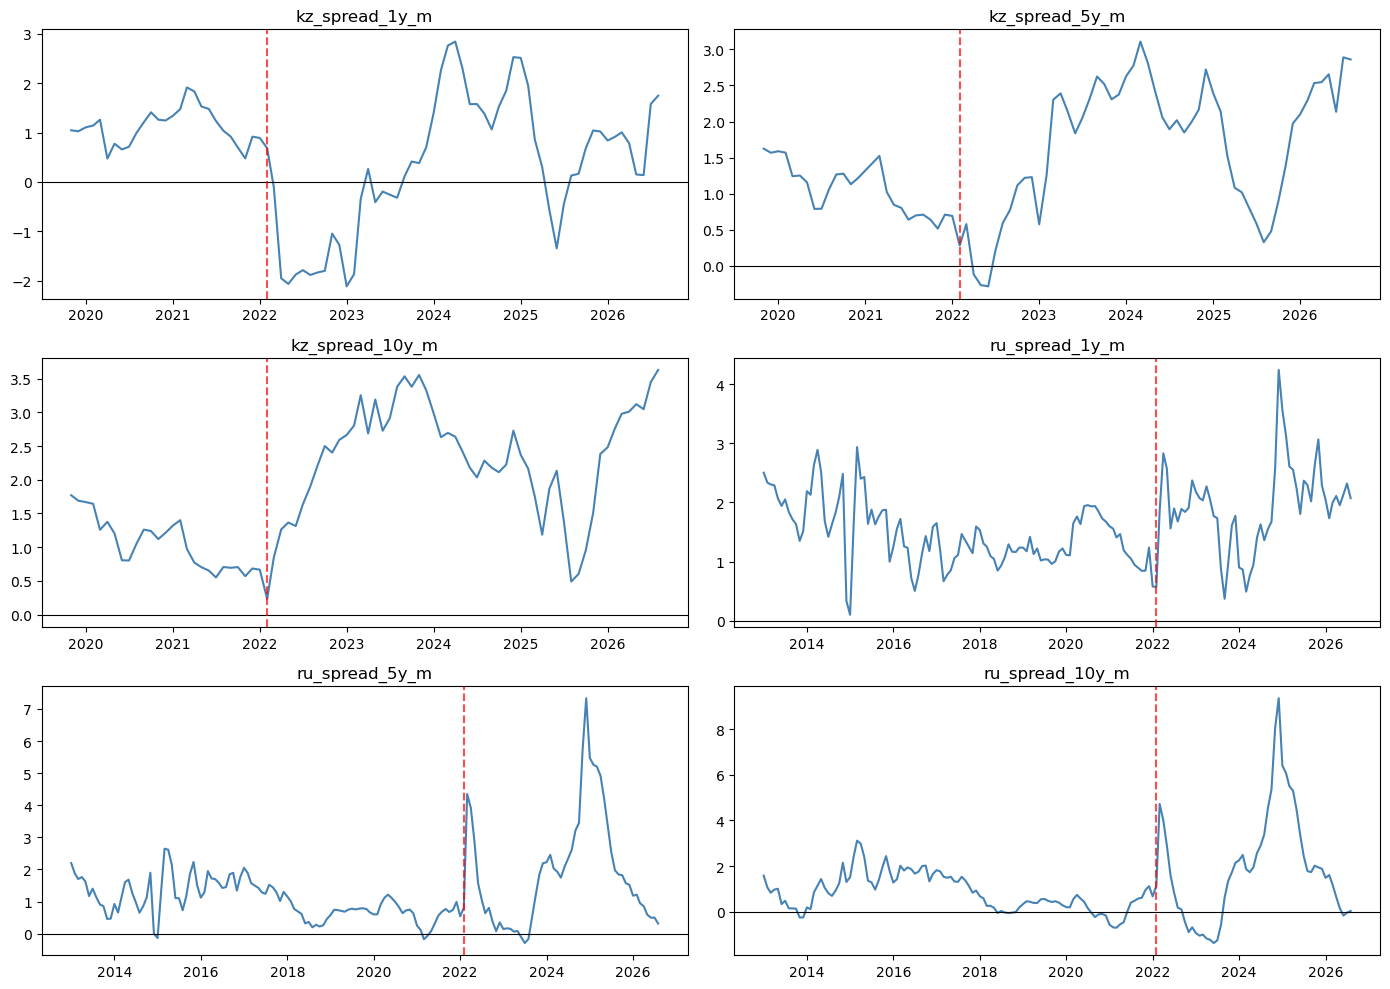


kz_spread_1y_m: 20 negative observations
date
2022-03-01   -0.108149
2022-04-01   -1.948870
2022-05-01   -2.061544
2022-06-01   -1.872665
2022-07-01   -1.783037
2022-08-01   -1.880591
2022-09-01   -1.829917
2022-10-01   -1.797520
2022-11-01   -1.044887
2022-12-01   -1.272052
2023-01-01   -2.111264
2023-02-01   -1.863082
2023-03-01   -0.338295
2023-05-01   -0.408795
2023-06-01   -0.193726
2023-07-01   -0.257431
2023-08-01   -0.318325
2025-05-01   -0.561086
2025-06-01   -1.341557
2025-07-01   -0.446758
Name: kz_spread_1y_m, dtype: float64

kz_spread_5y_m: 3 negative observations
date
2022-04-01   -0.118649
2022-05-01   -0.266473
2022-06-01   -0.283966
Name: kz_spread_5y_m, dtype: float64

ru_spread_5y_m: 6 negative observations
date
2015-01-01   -0.136842
2021-03-01   -0.173636
2021-04-01   -0.062727
2023-06-01   -0.110952
2023-07-01   -0.290952
2023-08-01   -0.163478
Name: ru_spread_5y_m, dtype: float64

ru_spread_10y_m: 30 negative observations
date
2013-11-01   -0.242500
2013-12-01  

In [26]:
import matplotlib.pyplot as plt

# ── STEP 1: Inspect raw magnitudes to confirm the units mismatch ────────────
print("=== GDP vs External Debt — raw magnitude check ===")
print("\nKZ:")
print(master[["kz_extdebt_m", "kz_gdp_m"]].describe())
print("\nRU:")
print(master[["ru_extdebt_m", "ru_gdp_m"]].describe())

print("\n=== M2 vs Reserves — raw magnitude check ===")
print("\nKZ:")
print(master[["kz_m2_m", "kz_reserves_m", "kz_usdfx_m"]].describe())
print("\nRU:")
print(master[["ru_m2_m", "ru_reserves_m", "ru_usdfx_m"]].describe())

# ── STEP 2: Convert M2 (local currency) to USD before the reserves/M2 ratio ──
master["kz_m2_usd"] = master["kz_m2_m"] / master["kz_usdfx_m"]
master["ru_m2_usd"] = master["ru_m2_m"] / master["ru_usdfx_m"]

master["kz_reserves_m2_ratio"] = master["kz_reserves_m"] / master["kz_m2_usd"]
master["ru_reserves_m2_ratio"] = master["ru_reserves_m"] / master["ru_m2_usd"]

# ── STEP 3: External debt/GDP — GDP is very likely in LOCAL currency (tenge/
# ruble), while external debt is USD. Convert GDP to USD using the same FX
# series before dividing. Verify against your data dictionary: if GDP was
# already sourced in USD (e.g., via FRED's ru_gdp_m from NGDPRNSAXDCRUQ),
# this conversion should NOT be applied — check the printed magnitudes above
# first to decide which case you're in. ─────────────────────────────────────
master["kz_gdp_usd"] = master["kz_gdp_m"] / master["kz_usdfx_m"]
master["ru_gdp_usd"] = master["ru_gdp_m"] / master["ru_usdfx_m"]

master["kz_extdebt_gdp_ratio"] = master["kz_extdebt_m"] / master["kz_gdp_usd"]
master["ru_extdebt_gdp_ratio"] = master["ru_extdebt_m"] / master["ru_gdp_usd"]

print("\n=== Corrected ratios ===")
display(master[["kz_extdebt_gdp_ratio", "ru_extdebt_gdp_ratio",
                 "kz_reserves_m2_ratio", "ru_reserves_m2_ratio"]].describe())

# ── STEP 4: Diagnose negative spreads — plot with war-onset line ────────────
war_onset = pd.Timestamp("2022-02-01")
spread_cols = ["kz_spread_1y_m", "kz_spread_5y_m", "kz_spread_10y_m",
               "ru_spread_1y_m", "ru_spread_5y_m", "ru_spread_10y_m"]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, spread_cols):
    ax.plot(master.index, master[col], color="steelblue")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.axvline(war_onset, color="red", linestyle="--", alpha=0.7)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Flag exactly which dates have negative spreads, for each series
for col in spread_cols:
    neg_dates = master.loc[master[col] < 0, col].dropna()
    if len(neg_dates) > 0:
        print(f"\n{col}: {len(neg_dates)} negative observations")
        print(neg_dates)

In [27]:
# ── External debt/GDP: debt is a STOCK, GDP-as-sourced is a MONTHLY FLOW —
# annualize GDP via trailing 12-month sum before forming the ratio ──────────
master["kz_gdp_annual_usd"] = master["kz_gdp_usd"].rolling(window=12, min_periods=12).sum()
master["ru_gdp_annual_usd"] = master["ru_gdp_usd"].rolling(window=12, min_periods=12).sum()

master["kz_extdebt_gdp_ratio"] = master["kz_extdebt_m"] / master["kz_gdp_annual_usd"]
master["ru_extdebt_gdp_ratio"] = master["ru_extdebt_m"] / master["ru_gdp_annual_usd"]

print("=== Corrected (annualized) ratios ===")
display(master[["kz_extdebt_gdp_ratio", "ru_extdebt_gdp_ratio"]].describe())

=== Corrected (annualized) ratios ===


,kz_extdebt_gdp_ratio,ru_extdebt_gdp_ratio
count,136.000000,124.000000
mean,0.850870,0.233098
std,0.181731,0.034435
min,0.593946,0.164600
25%,0.687288,0.198756
50%,0.876147,0.240182
75%,0.960181,0.261893
max,1.245165,0.290395


## Notes on Constructed Variables: Ratios and Credit Spreads

### External debt-to-GDP ratio: flow/stock correction

External debt is a **stock** variable (measured at a point in time), while GDP
as sourced in this dataset is disaggregated from quarterly to **monthly** flows
(via industrial-production-share pro-rata allocation, per the data dictionary).
Dividing a debt stock directly by a monthly GDP flow overstates the conventional
debt-to-GDP ratio by roughly a factor of 12. This was corrected by annualizing
GDP using a trailing 12-month rolling sum before forming the ratio:

$$
\text{ExtDebt/GDP}_t = \frac{\text{ExtDebt}_t}{\sum_{i=0}^{11} \text{GDP}_{t-i}}
$$

This produces economically plausible magnitudes (Kazakhstan ≈ 87% of GDP,
Russia ≈ 24% of GDP, consistent with each country's known external indebtedness
profile) and introduces 11 months of `NaN` at the start of each GDP series,
where a full trailing-12-month window is not yet available. This is treated as
a genuine data limitation rather than filled or estimated, to avoid overstating
early-sample coverage with an artificially short annualization window.

### Reserves-to-M2 ratio: no correction required

Both international reserves and M2 money supply are stock variables, so no
flow/stock adjustment applies. Elevated values in the early 2000s (where M2 was
still very small relative to reserves) reflect genuine early-transition monetary
conditions rather than a construction error, and are retained as-is.

### Negative credit spreads: two distinct patterns

Six spread series were constructed as corporate yield index minus government
bond yield at matched maturity. Negative values (corporate yield below
government yield) occurred in two distinct patterns, interpreted differently:

**Kazakhstan (1yr, 5yr):** Negative spreads cluster almost entirely in the
period immediately following February 2022, extending through 2023, with a
smaller recurrence in 2025. This is consistent with Kazakhstan's National Bank
sharply raising short-term policy rates in response to war-driven capital
outflows and inflationary pressure, with government yields at short maturities
repricing faster than the corporate bond index. Rather than a data artifact,
this pattern is treated as a substantive finding directly relevant to this
paper's research question, and is retained in the dataset without adjustment.

**Russia (10yr):** Negative spreads recur intermittently across the full sample
(2013, 2018, 2020-21, 2022-23), with no concentration around the 2022 invasion
specifically. Because this pattern predates the war by nearly a decade, it is
attributed to the construction of the underlying government yield series —
sourced from MOEX's published zero-coupon yield curve (ZCYC) *parameters*, a
fitted/modeled curve rather than directly observed long-maturity transaction
yields — which can behave irregularly at the long end of an emerging-market
curve, particularly during periods of thin trading. This is documented as a
data-construction caveat rather than an economically meaningful result, and the
series is likewise retained without adjustment, since artificially flooring the
spread at zero would misrepresent the underlying data.

**General principle:** no negative spread values were removed, winsorized, or
floored at zero. Suppressing them would discard genuine information — in one
case a plausible war-related finding, in the other a known limitation of a
fitted government curve — either of which is more informative left visible and
explained than hidden.

#### Notebook 02 · Block 8 · War Dummy + Locally-computed volatility (KASE, MOEX)

war_dummy
0    417
1     55
Name: count, dtype: int64

KZ volatility — non-null obs: 311
RU volatility — non-null obs: 317


,kz_vol_m,ru_vol_m
count,311.000000,317.000000
mean,0.043927,0.049574
std,0.042703,0.036438
min,0.001985,0.003120
25%,0.018308,0.022881
50%,0.033044,0.039018
75%,0.054928,0.064123
max,0.313668,0.244156


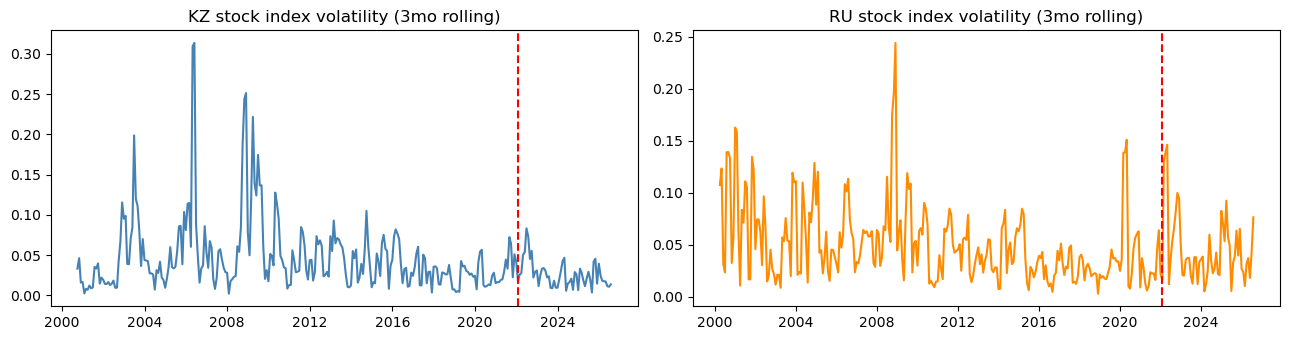

In [28]:
# ── War dummy ─────────────────────────────────────────────────────────────
war_onset = pd.Timestamp("2022-02-01")
master["war_dummy"] = (master.index >= war_onset).astype(int)
print(master["war_dummy"].value_counts())

# ── Volatility from rolling returns ──────────────────────────────────────────
# Standard approach: compute monthly log returns on the stock index level,
# then take a rolling standard deviation as the volatility proxy.
# Since your data is already monthly (not daily), "rolling returns" here means
# a rolling window OF the monthly return series — if you have access to the
# underlying DAILY KASE/MOEX data, realized volatility computed from daily
# returns within each month is a materially better proxy. Confirm which you
# have before trusting this monthly-only version.

master["kz_stockidx_ret"] = np.log(master["kz_stockidx_m"]).diff()
master["ru_stockidx_ret"] = np.log(master["ru_stockidx_m"]).diff()

ROLL_WINDOW = 3  # 3-month rolling window 

master["kz_vol_m"] = master["kz_stockidx_ret"].rolling(window=ROLL_WINDOW, min_periods=ROLL_WINDOW).std()
master["ru_vol_m"] = master["ru_stockidx_ret"].rolling(window=ROLL_WINDOW, min_periods=ROLL_WINDOW).std()

print(f"\nKZ volatility — non-null obs: {master['kz_vol_m'].notna().sum()}")
print(f"RU volatility — non-null obs: {master['ru_vol_m'].notna().sum()}")

display(master[["kz_vol_m", "ru_vol_m"]].describe())

# Quick visual — volatility should visibly spike around known stress periods
# (2008 GFC, 2014-15 oil crash/RUB devaluation, 2022 war) as a sanity check
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(master.index, master["kz_vol_m"], color="steelblue")
axes[0].axvline(war_onset, color="red", linestyle="--")
axes[0].set_title("KZ stock index volatility (3mo rolling)")
axes[1].plot(master.index, master["ru_vol_m"], color="darkorange")
axes[1].axvline(war_onset, color="red", linestyle="--")
axes[1].set_title("RU stock index volatility (3mo rolling)")
plt.tight_layout()
plt.show()

#### Notebook 02 · Block 9 · Assemble master dataset (Levels + Transformed) & Save

In [30]:
import os

RESULTS_DIR = "/Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data/Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Stationarity test on newly constructed variables: spreads, ratios,
# volatility (war_dummy needs no transform — binary indicator) ──────────────
new_vars = [
    "kz_spread_1y_m", "kz_spread_5y_m", "kz_spread_10y_m",
    "ru_spread_1y_m", "ru_spread_5y_m", "ru_spread_10y_m",
    "kz_extdebt_gdp_ratio", "ru_extdebt_gdp_ratio",
    "kz_reserves_m2_ratio", "ru_reserves_m2_ratio",
    "kz_vol_m", "ru_vol_m",
]

if "transformed_series_new" not in dir() or "summary_table_new" not in dir():
    print("Running stationarity tests on spreads/ratios/volatility...")

    for v in new_vars:
        if v not in rate_type_vars:
            rate_type_vars.append(v)

    summary_rows_new = []
    transformed_series_new = {}

    for var in new_vars:
        raw = master[var].dropna()
        if len(raw) < 20:
            print(f"  ⚠ {var}: too few observations ({len(raw)}), skipping")
            continue

        adf_raw, adfp_raw = run_adf(raw)
        kpss_raw, kpssp_raw = run_kpss(raw)
        raw_stationary = is_stationary(adfp_raw, kpssp_raw)

        if raw_stationary:
            chosen = "none_needed"
            transformed_series_new[var] = raw
            final_adf_p, final_kpss_p = adfp_raw, kpssp_raw
        else:
            results = compute_transform_candidates(raw)
            chosen = choose_best_transform(results, var)
            if chosen == "none_passed":
                chosen = preferred_transform_for(var) or "diff"
            best = results[chosen]
            transformed_series_new[var] = best["series"]
            final_adf_p, final_kpss_p = best["adf_p"], best["kpss_p"]

        summary_rows_new.append(dict(
            variable=var,
            preferred_transform=preferred_transform_for(var),
            adf_p_raw=round(adfp_raw, 4),
            kpss_p_raw=round(kpssp_raw, 4),
            raw_stationary=raw_stationary,
            transform_applied=chosen,
            adf_p_final=round(final_adf_p, 4),
            kpss_p_final=round(final_kpss_p, 4),
            passed_both_tests=is_stationary(final_adf_p, final_kpss_p),
        ))

    summary_table_new = pd.DataFrame(summary_rows_new)
    display(summary_table_new)

    still_failing_new = summary_table_new[~summary_table_new["passed_both_tests"]]
    if len(still_failing_new) > 0:
        print(f"\n⚠ {len(still_failing_new)} new variable(s) still fail stationarity — review before treating as final:")
        display(still_failing_new)
    else:
        print("\n✓ All new variables (spreads/ratios/volatility) pass stationarity.")
else:
    print("transformed_series_new / summary_table_new already exist — using existing results.")

# ── Sheet 1: Raw/level dataset — every constructed variable traceable to source ──
levels_export = master.copy().reset_index()

# ── Sheet 2: Transformed (stationary) dataset ────────────────────────────────
all_transformed = {**transformed_series, **transformed_series_new}
transformed_export = pd.DataFrame(all_transformed)
transformed_export["war_dummy"] = master["war_dummy"]
transformed_export = transformed_export.reset_index()

# ── Sheet 3: Codebook ─────────────────────────────────────────────────────────
full_summary = pd.concat([summary_table, summary_table_new], ignore_index=True)
codebook = full_summary[["variable", "transform_applied", "adf_p_final", "kpss_p_final", "passed_both_tests"]].copy()
codebook = pd.concat([
    codebook,
    pd.DataFrame([{
        "variable": "war_dummy", "transform_applied": "none (binary indicator)",
        "adf_p_final": np.nan, "kpss_p_final": np.nan, "passed_both_tests": True
    }])
], ignore_index=True)

# ── Sanity check before saving ────────────────────────────────────────────────
unresolved = codebook[codebook["passed_both_tests"] == False]
if len(unresolved) > 0:
    print(f"\n⚠ WARNING: {len(unresolved)} variable(s) have NOT passed stationarity testing:")
    display(unresolved)
else:
    print(f"\n✓ All {len(codebook)} variables in the codebook have passed stationarity (or are the war dummy).")

# ── Duplicate-index guard: confirm the earlier duplicate-date fix is still
# in effect before saving, since a duplicated index would silently corrupt
# the DataFrame construction above ───────────────────────────────────────────
assert not master.index.duplicated().any(), "master still has duplicate dates — resolve before saving"
assert not transformed_export["date"].duplicated().any(), "transformed_export has duplicate dates"

# ── Save all three sheets into one workbook ──────────────────────────────────
output_path_final = f"{RESULTS_DIR}/master_dataset_final.xlsx"

with pd.ExcelWriter(output_path_final, engine="openpyxl") as writer:
    levels_export.to_excel(writer, sheet_name="Levels (Raw)", index=False)
    transformed_export.to_excel(writer, sheet_name="Transformed (Stationary)", index=False)
    codebook.to_excel(writer, sheet_name="Codebook", index=False)

print(f"\nSaved: {output_path_final}")
print(f"Levels shape: {levels_export.shape}")
print(f"Transformed shape: {transformed_export.shape}")
print(f"Codebook rows: {len(codebook)}")

transformed_series_new / summary_table_new already exist — using existing results.

✓ All 48 variables in the codebook have passed stationarity (or are the war dummy).

Saved: /Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data/Results/master_dataset_final.xlsx
Levels shape: (472, 57)
Transformed shape: (471, 49)
Codebook rows: 48


In [32]:
# VERIFY: check transform_applied for each spread variable in the saved codebook
codebook[codebook["variable"].str.contains("spread")]

,variable,transform_applied,adf_p_final,kpss_p_final,passed_both_tests
35,kz_spread_1y_m,diff,0.0000,0.1,True
36,kz_spread_5y_m,diff,0.0000,0.1,True
37,kz_spread_10y_m,diff,0.0000,0.1,True
38,ru_spread_1y_m,none_needed,0.0067,0.1,True
39,ru_spread_5y_m,none_needed,0.0367,0.1,True
40,ru_spread_10y_m,none_needed,0.0244,0.1,True
